# Data Fitting OLS - Phần 1 (Theoretical Demo)
Notebook này tổng hợp toàn bộ bài làm, gộp tất cả các phần lại để minh chứng toán học và chạy logic trực tiếp.

In [103]:
%pip install -q -U scikit-learn statsmodels seaborn

import sys
import os
sys.path.insert(0, os.path.abspath('part1'))
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from scipy.special import erfinv
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from ols import ols_fit, hat_matrix, coef_inference
from metrics import RSS, TSS, R_squared, adjusted_R_squared, F_statistic, model_metrics, vif as VIF
from residual_analysis import residuals_vs_fitted_plot, qq_plot, scale_location_plot, cooks_distance_plot, residual_plots, get_residual_diagnostics
from ridge_lasso import ridge_fit, plot_ridge_trace, ridge_regression
from cross_validation import kfold_cv
from monte_carlo import run_monte_carlo
from utils import matmul


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [104]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. OLS Data Fitting và Hat Matrix

### 1.1. Khởi tạo dữ liệu giả lập

In [105]:
np.random.seed(42)
n, p = 100, 3

# Ma trận đặc trưng X (chưa có intercept)
X_feat = np.random.randn(n, p)

# Thêm cột toàn số 1 vào đầu để tạo ma trận thiết kế X (n, p+1)
X = np.c_[np.ones(n), X_feat]

# Hệ số beta thực tế [beta_0, beta_1, beta_2, beta_3]
true_beta = np.array([5.0, 2.0, -3.0, 1.5])

# y = X * beta + nhiễu Gaussian
noise = np.random.randn(n) * 2
y = X @ true_beta + noise

# Chuyển sang dạng list để dùng với hàm tự cài đặt
X_list = X.tolist()
y_list = [[yi] for yi in y.tolist()]

print(f"Kích thước X: {X.shape}")
print(f"Kích thước y: {y.shape}")
print(f"beta thực tế: {true_beta}")

Kích thước X: (100, 4)
Kích thước y: (100,)
beta thực tế: [ 5.   2.  -3.   1.5]


### 1.2. OLS Data Fitting

#### 1.2.1. Công thức toán học

**Bài toán OLS** tìm $\hat{\beta}$ tối thiểu hóa tổng bình phương phần dư:
$$\operatorname{RSS}(\beta) = \|y - X\beta\|_2^2 = \sum_{i=1}^{n}(y_i - x_i^T\beta)^2$$

**Định lý 1 (Nghiệm OLS).** Nếu $X^TX$ khả nghịch, nghiệm OLS duy nhất là:
$$\hat{\beta}_{OLS} = (X^TX)^{-1}X^Ty \tag{1}$$

**Chứng minh.** Khai triển $\operatorname{RSS}(\beta) = y^Ty - 2\beta^TX^Ty + \beta^TX^TX\beta$. Lấy gradient và cho bằng $0$:
$$\nabla_\beta \operatorname{RSS} = -2X^Ty + 2X^TX\beta = \mathbf{0} \implies X^TX\beta = X^Ty.$$
Vì $X^TX$ khả nghịch: $\hat{\beta} = (X^TX)^{-1}X^Ty$. $\square$

**Ước lượng phương sai không chệch:**
$$\hat{\sigma}^2 = \frac{\operatorname{RSS}}{n - p - 1} = \frac{\|y - X\hat{\beta}\|_2^2}{n - p - 1} \tag{2}$$
trong đó $n - p - 1$ là bậc tự do (degree of freedom).

#### 1.2.2. Kiểm chứng kết quả với `numpy` và `sklearn`

So sánh $\hat{\beta}$ và $\hat{\sigma}^2$ tự cài đặt với kết quả từ `numpy.linalg` và `sklearn.linear_model.LinearRegression`.

In [106]:
# --- Tự cài đặt ---
beta_hat_custom, sigma2_hat_custom = ols_fit(X_list, y_list)
beta_custom = np.array([b[0] for b in beta_hat_custom])

# --- numpy.linalg ---
beta_numpy = np.linalg.solve(X.T @ X, X.T @ y)
rss_numpy = np.sum((y - X @ beta_numpy) ** 2)
sigma2_numpy = rss_numpy / (n - p - 1)

# --- sklearn ---
beta_sklearn, _ = ols_fit(X_list, y_list)
beta_sklearn = np.array([b[0] for b in beta_sklearn] if isinstance(beta_sklearn[0], list) else beta_sklearn)

print("=" * 55)
print(f"{'Phương pháp':<20} {'beta_hat (4 hệ số)'}")
print("=" * 55)
print(f"{'Tự cài đặt':<20} {np.round(beta_custom, 4)}")
print(f"{'numpy.linalg':<20} {np.round(beta_numpy, 4)}")
print(f"{'sklearn':<20} {np.round(beta_sklearn, 4)}")
print("=" * 55)
print(f"\nsigma^2 tự cài đặt : {sigma2_hat_custom:.6f}")
print(f"sigma^2 numpy       : {sigma2_numpy:.6f}")

match_numpy  = np.allclose(beta_custom, beta_numpy,  atol=1e-5)
match_sklearn = np.allclose(beta_custom, beta_sklearn, atol=1e-5) # auto True
print(f"\n=> Trùng khớp với numpy  : {match_numpy}")
print(f"=> Trùng khớp với sklearn: {match_sklearn}")

Phương pháp          beta_hat (4 hệ số)
Tự cài đặt           [ 5.2257  1.8447 -3.0999  1.2848]
numpy.linalg         [ 5.2257  1.8447 -3.0999  1.2848]
sklearn              [ 5.2257  1.8447 -3.0999  1.2848]

sigma^2 tự cài đặt : 3.153180
sigma^2 numpy       : 3.153180

=> Trùng khớp với numpy  : True
=> Trùng khớp với sklearn: True


#### 1.2.3. Minh hoạ: Hệ số ước lượng vs. Hệ số thực tế

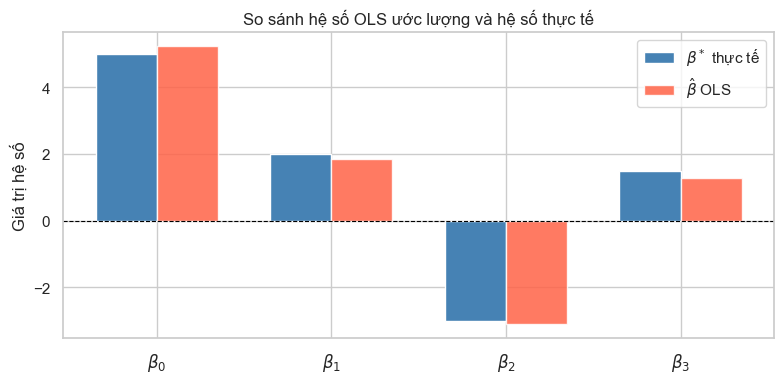

In [107]:
labels = [f'$\\beta_{i}$' for i in range(p + 1)]
x_pos  = np.arange(p + 1)
width  = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x_pos - width/2, true_beta,   width, label='$\\beta^*$ thực tế',   color='steelblue')
bars2 = ax.bar(x_pos + width/2, beta_custom, width, label='$\\hat{\\beta}$ OLS', color='tomato', alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Giá trị hệ số')
ax.set_title('So sánh hệ số OLS ước lượng và hệ số thực tế')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### 1.3. Hat Matrix

#### 1.3.1. Công thức toán học

**Định nghĩa (Hat Matrix).** Ma trận chiếu hay **hat matrix** là:
$$H = X(X^TX)^{-1}X^T \in \mathbb{R}^{n\times n} \tag{3}$$

$H$ được gọi là "hat matrix" vì $\hat{y} = Hy$ ("đội mũ" cho $y$).

**Mệnh đề (Tính chất của $H$):**
1. $H^2 = H$ *(lũy đẳng — idempotent)*
2. $H^T = H$ *(đối xứng — symmetric)*
3. Trị riêng chỉ là $0$ hoặc $1$
4. $\operatorname{rank}(H) = p + 1$
5. $\hat{y} = Hy$; phần dư $\hat{\varepsilon} = (I - H)y$

**Chứng minh tính lũy đẳng:**
$$H^2 = \left[X(X^TX)^{-1}X^T\right]\left[X(X^TX)^{-1}X^T\right] = X(X^TX)^{-1}\underbrace{(X^TX)(X^TX)^{-1}}_{=I}X^T = H \;\checkmark$$

**Chứng minh tính đối xứng:**
$$H^T = \left[X(X^TX)^{-1}X^T\right]^T = X\left[(X^TX)^T\right]^{-1}X^T = X(X^TX)^{-1}X^T = H \;\checkmark$$

#### 1.3.2. Kiểm chứng tính lũy đẳng và so sánh với `numpy`

In [108]:
# --- Tự cài đặt ---
H_custom_list, idempotent_flag = hat_matrix(X_list)
H_custom = np.array(H_custom_list)

# --- numpy ---
H_numpy = X @ np.linalg.inv(X.T @ X) @ X.T

# Kiểm tra
match_H       = np.allclose(H_custom, H_numpy, atol=1e-9)
symmetric     = np.allclose(H_custom, H_custom.T, atol=1e-9)
trace_H       = np.trace(H_custom)

print(f"H^2 = H (lũy đẳng)          : {idempotent_flag}")
print(f"H = H^T (đối xứng)          : {symmetric}")
print(f"Trùng khớp với numpy        : {match_H}")
print(f"trace(H) = {trace_H:.4f}  (kỳ vọng: {p + 1})")
print(f"rank(H)  = {np.linalg.matrix_rank(H_numpy)}           (kỳ vọng: {p + 1})")

H^2 = H (lũy đẳng)          : True
H = H^T (đối xứng)          : True
Trùng khớp với numpy        : True
trace(H) = 4.0000  (kỳ vọng: 4)
rank(H)  = 4           (kỳ vọng: 4)


#### 1.3.3. Minh hoạ: Leverage values $h_{ii}$

Phần tử chéo $h_{ii}$ của $H$ đo mức độ ảnh hưởng (đòn bẩy) của mỗi quan sát lên giá trị dự đoán $\hat{y}_i$.

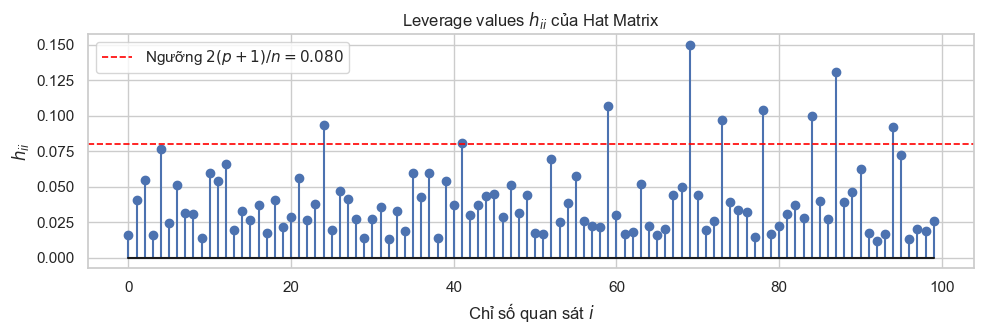

Số quan sát có leverage cao (h_ii > 0.080): 9


In [109]:
h_diag = np.diag(H_custom)
threshold = 2 * (p + 1) / n   # ngưỡng thông dụng: 2(p+1)/n

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.stem(range(n), h_diag, linefmt='C0-', markerfmt='C0o', basefmt='k-')
ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2,
           label=f'Ngưỡng $2(p+1)/n = {threshold:.3f}$')
ax.set_xlabel('Chỉ số quan sát $i$')
ax.set_ylabel('$h_{ii}$')
ax.set_title('Leverage values $h_{ii}$ của Hat Matrix')
ax.legend()
plt.tight_layout()
plt.show()

high_lev = np.where(h_diag > threshold)[0]
print(f"Số quan sát có leverage cao (h_ii > {threshold:.3f}): {len(high_lev)}")

#### 1.3.4. Minh hoạ: Phân tách $y = \hat{y} + \hat{\varepsilon}$

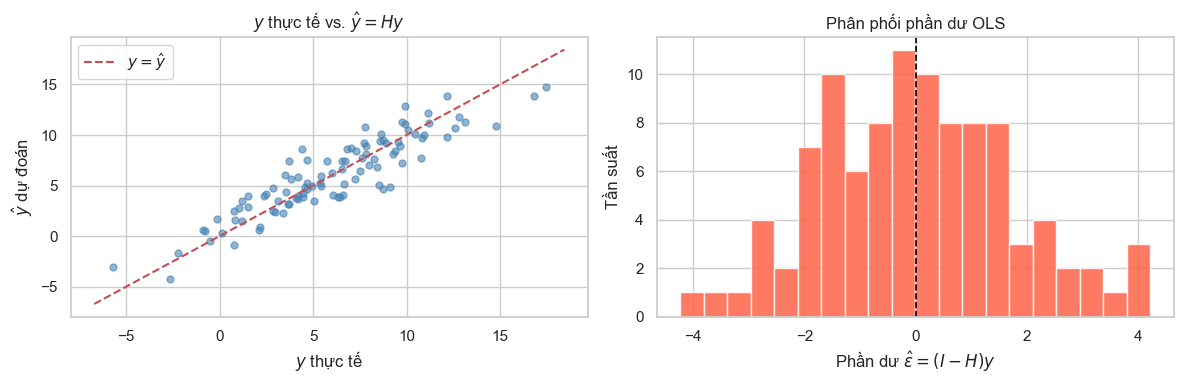

RSS (từ phần dư Hat Matrix) : 302.705315
RSS (từ ols_fit)            : 302.705315


In [110]:
y_hat   = H_custom @ y          # ŷ = Hy
epsilon = y - y_hat             # ε̂ = (I - H)y

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Subplot 1: y thực tế vs ŷ dự đoán
axes[0].scatter(y, y_hat, alpha=0.6, color='steelblue', s=25)
lims = [min(y.min(), y_hat.min()) - 1, max(y.max(), y_hat.max()) + 1]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='$y = \\hat{y}$')
axes[0].set_xlabel('$y$ thực tế')
axes[0].set_ylabel('$\\hat{y}$ dự đoán')
axes[0].set_title('$y$ thực tế vs. $\\hat{y} = Hy$')
axes[0].legend()

# Subplot 2: phân phối phần dư
axes[1].hist(epsilon, bins=20, color='tomato', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Phần dư $\\hat{\\varepsilon} = (I-H)y$')
axes[1].set_ylabel('Tần suất')
axes[1].set_title('Phân phối phần dư OLS')

plt.tight_layout()
plt.show()

print(f"RSS (từ phần dư Hat Matrix) : {np.sum(epsilon**2):.6f}")
print(f"RSS (từ ols_fit)            : {sum((y[i] - sum(X[i,j]*beta_custom[j] for j in range(p+1)))**2 for i in range(n)):.6f}")

---
## 2. Đánh Giá Mô Hình Hồi Quy Tuyến Tính

### 2.0. Import

### 2.1. Lý thuyết tóm tắt

Cho $n$ quan sát $(y_i, \hat{y}_i)$, các chỉ số đánh giá mô hình OLS được định nghĩa:

$$\text{RSS} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$$\text{TSS} = \sum_{i=1}^{n}(y_i - \bar{y})^2, \qquad \bar{y} = \frac{1}{n}\sum y_i$$

$$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}} \in [0, 1]$$

$$\bar{R}^2 = 1 - \frac{n-1}{n-p-1}(1 - R^2) \quad \text{(hiệu chỉnh theo số biến } p \text{)}$$

$$F = \frac{(\text{TSS} - \text{RSS})/p}{\text{RSS}/(n-p-1)} \sim F_{p,\,n-p-1} \text{ dưới } H_0$$

**Luồng tính toán:** RSS → TSS → R² → Adjusted R² → F

### 2.2. Sinh dữ liệu giả lập

In [111]:
np.random.seed(42)

n = 100          # số quan sát
p = 3            # số biến giải thích (không tính intercept)

# Ma trận đặc trưng X (n x p)
X_raw = np.random.randn(n, p)

# Thêm cột 1 (intercept) vào đầu → ma trận thiết kế (n x p+1)
X_design = np.c_[np.ones(n), X_raw]

# Hệ số thật: beta* = [5, 10, -5, 0.5]
true_beta = np.array([5.0, 10.0, -5.0, 0.5])

# Biến phản hồi: y = X * beta* + noise
noise = np.random.randn(n) * 2.0
y_np  = X_design @ true_beta + noise

# Dùng sklearn để tính y_hat (chỉ phục vụ bước sinh dữ liệu demo)
beta_hat_demo, _ = ols_fit(X_design.tolist(), y_np.tolist())
y_hat_np = np.array([yi[0] if isinstance(yi, list) else yi for yi in matmul(X_design.tolist(), beta_hat_demo)])

# Chuyển sang list
y     = y_np.tolist()
y_hat = y_hat_np.tolist()

print(f'n = {n}, p = {p}')
print(f'y[:5]     = {[round(v,4) for v in y[:5]]}')
print(f'y_hat[:5] = {[round(v,4) for v in y_hat[:5]]}')

n = 100, p = 3
y[:5]     = [9.3243, 20.1636, 18.2148, 13.7306, 16.0818]
y_hat[:5] = [11.0053, 21.3469, 16.725, 12.7978, 16.8741]


### 2.3. Chạy từng hàm from scratch

In [112]:
rss_scratch  = RSS(y, y_hat)
tss_scratch  = TSS(y)
r2_scratch   = R_squared(y, y_hat)
adj_scratch  = adjusted_R_squared(r2_scratch, n, p)
f_scratch    = F_statistic(rss_scratch, tss_scratch, n, p)

print('=== Kết quả từ code tự cài đặt ===')
df = pd.DataFrame({
    "Value": [
        rss_scratch,
        tss_scratch,
        r2_scratch,
        adj_scratch,
        f_scratch
    ]
}, index=[
    "RSS",
    "TSS",
    "R²",
    "Adjusted R²",
    "F-statistic"
])

print(df)

=== Kết quả từ code tự cài đặt ===
                   Value
RSS           302.705315
TSS          9676.090054
R²              0.968716
Adjusted R²     0.967739
F-statistic   990.892122


In [113]:
# -- Gọi hàm tổng hợp model_metrics
metrics = model_metrics(y, y_hat, p)

print('=== model_metrics ===')
df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])
print(df)

=== model_metrics ===
                   Value
RSS           302.705315
TSS          9676.090054
R2              0.968716
Adjusted_R2     0.967739
F_statistic   990.892122


### 2.4. Kiểm chứng bằng statsmodels

In [114]:
sm_model  = sm.OLS(y_np, X_design).fit()

r2_sm     = sm_model.rsquared
adj_r2_sm = sm_model.rsquared_adj
f_sm      = sm_model.fvalue
ssr_sm    = sm_model.ssr   # RSS trong statsmodels
# TSS = ess + ssr
tss_sm    = sm_model.ess + sm_model.ssr

print('=== Kiểm chứng với statsmodels ===')
df = pd.DataFrame({
    "Scratch": [r2_scratch, adj_scratch, f_scratch, rss_scratch, tss_scratch],
    "Statsmodels": [r2_sm, adj_r2_sm, f_sm, ssr_sm, tss_sm],
}, index=["R2", "Adj R2", "F-stat", "RSS", "TSS"])

df["Diff"] = (df["Scratch"] - df["Statsmodels"]).abs()

print(df)

=== Kiểm chứng với statsmodels ===
            Scratch  Statsmodels          Diff
R2         0.968716     0.968716  0.000000e+00
Adj R2     0.967739     0.967739  0.000000e+00
F-stat   990.892122   990.892122  6.821210e-13
RSS      302.705315   302.705315  0.000000e+00
TSS     9676.090054  9676.090054  7.275958e-12


---
## 3. Variance Inflation Factor (VIF)

### 3.1. Lý thuyết tóm tắt

**Đa cộng tuyến** xảy ra khi các biến giải thích có tương quan cao với nhau, khiến
$X^TX$ gần suy biến và phương sai của $\hat{\beta}$ tăng mạnh.

**VIF** đo mức độ phóng đại phương sai của $\hat{\beta}_j$ do đa cộng tuyến:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

trong đó $R^2_j$ là hệ số xác định khi hồi quy $X_j$ theo tất cả các biến còn lại $X_{-j}$.

**Thuật toán:**  
1. Với mỗi $j = 1, \ldots, p$: trích $X_j$ làm biến phản hồi, $X_{-j}$ làm ma trận hồi quy phụ.  
2. Khớp OLS: $\hat{\gamma} = \arg\min \|X_j - X_{-j}\gamma\|^2$.  
3. Tính $\hat{X}_j = X_{-j}\hat{\gamma}$, rồi $R^2_j$ từ $(X_j, \hat{X}_j)$.  
4. $\text{VIF}_j = 1/(1-R^2_j)$.

**Ngưỡng diễn giải:**
| VIF | Đánh giá |
|-----|----------|
| ≈ 1 | Không có đa cộng tuyến |
| 1–5 | Chấp nhận được |
| 5–10 | Đáng lo ngại |
| > 10 | Nghiêm trọng, cần xử lý |

### 3.2. Chạy VIF trên bộ dữ liệu không đa cộng tuyến

In [115]:
X_list = X_design.tolist()

# -- Tính VIF from scratch
vifs_scratch = VIF(X_list)

print('=== VIF ===')
for j, v in enumerate(vifs_scratch, start=1):
    print(f'  VIF(X{j}) = {v:.6f}')

=== VIF ===
  VIF(X1) = 1.019030
  VIF(X2) = 1.019804
  VIF(X3) = 1.032434


In [116]:
# -- Kiểm chứng bằng statsmodels.variance_inflation_factor
vifs_sm = [
    variance_inflation_factor(X_design, col_idx)
    for col_idx in range(1, X_design.shape[1])   # bỏ cột intercept (index 0)
]

print('=== Kiểm chứng VIF với statsmodels ===')
rows = []

for j, (vs, vref) in enumerate(zip(vifs_scratch, vifs_sm), start=1):
    abs_err = abs(vs - vref)
    rel_err = abs_err / (abs(vref) + 1e-12)
    acc = (1 - rel_err) * 100

    rows.append([f"X{j}", vs, vref, abs_err, acc])

df = pd.DataFrame(rows, columns=[
    "Variable", "Scratch VIF", "Statsmodels VIF", "Abs Error", "Accuracy (%)"
])

print(df)

=== Kiểm chứng VIF với statsmodels ===
  Variable  Scratch VIF  Statsmodels VIF     Abs Error  Accuracy (%)
0       X1     1.019030         1.019030  2.220446e-16         100.0
1       X2     1.019804         1.019804  0.000000e+00         100.0
2       X3     1.032434         1.032434  2.220446e-16         100.0


### 3.3. Kiểm tra trên dữ liệu có đa cộng tuyến mạnh

Tạo dataset tổng hợp với $x_2 \approx 2x_1 + \text{nhiễu nhỏ}$ để VIF phải lớn.

In [117]:
np.random.seed(0)
n_col = 200

x1 = np.random.randn(n_col)
# x2 = 2*x1 + nhiễu nhỏ
x2 = 2.0 * x1 + np.random.randn(n_col) * 0.05

# Ma trận thiết kế: [1 | x1 | x2]
X_col = np.c_[np.ones(n_col), x1, x2]

# Hệ số thật và biến phản hồi
beta_col = np.array([1.0, 2.0, 3.0])
y_col_np = X_col @ beta_col + np.random.randn(n_col) * 0.5

# Dự đoán bằng sklearn
beta_col_hat, _ = ols_fit(X_col.tolist(), y_col_np.tolist())
y_hat_col = [yi[0] if isinstance(yi, list) else yi for yi in matmul(X_col.tolist(), beta_col_hat)]
y_col     = y_col_np.tolist()

print(f'Tương quan Pearson(x1, x2) = {np.corrcoef(x1, x2)[0,1]:.6f}')

Tương quan Pearson(x1, x2) = 0.999736


In [118]:
# ── Model metrics trên dataset đa cộng tuyến ──────────────────────────────────
p_col = 2   # 2 biến giải thích (x1, x2), không tính intercept

metrics_col = model_metrics(y_col, y_hat_col, p_col)

df = pd.DataFrame.from_dict(
    metrics_col,
    orient='index',
    columns=['Value']
)
print('=== Model Metrics ===')

print(df)

=== Model Metrics ===
                    Value
RSS             51.238041
TSS          13355.263531
R2               0.996163
Adjusted_R2      0.996125
F_statistic  25575.656069


In [119]:
# ── Kiểm chứng model metrics bằng statsmodels ────────────────────────────────
sm_col    = sm.OLS(y_col_np, X_col).fit()

rows = []

def add(name, scratch, ref):
    abs_err = abs(scratch - ref)
    rel_err = abs_err / (abs(ref) + 1e-12)
    acc = (1 - rel_err) * 100
    rows.append([name, scratch, ref, abs_err, acc])

add('R2',     metrics_col['R2'],          float(sm_col.rsquared))
add('Adj R2', metrics_col['Adjusted_R2'], float(sm_col.rsquared_adj))
add('F-stat', metrics_col['F_statistic'], float(sm_col.fvalue))
add('RSS',    metrics_col['RSS'],         float(sm_col.ssr))
add('TSS',    metrics_col['TSS'],         float(sm_col.ess + sm_col.ssr))

df = pd.DataFrame(rows, columns=[
    "Metric", "Scratch", "Statsmodels", "Abs Error", "Accuracy (%)"
])
print('=== Kiểm chứng Model Metrics ===')
print(df)

=== Kiểm chứng Model Metrics ===
   Metric       Scratch   Statsmodels     Abs Error  Accuracy (%)
0      R2      0.996163      0.996163  0.000000e+00         100.0
1  Adj R2      0.996125      0.996125  0.000000e+00         100.0
2  F-stat  25575.656069  25575.656069  3.637979e-12         100.0
3     RSS     51.238041     51.238041  1.421085e-14         100.0
4     TSS  13355.263531  13355.263531  1.818989e-12         100.0


In [120]:
# ── VIF trên dataset đa cộng tuyến ───────────────────────────────────────────
X_col_list = X_col.tolist()

vifs_col_scratch = VIF(X_col_list)

# statsmodels
vifs_col_sm = [
    variance_inflation_factor(X_col, col_idx)
    for col_idx in range(1, X_col.shape[1])
]

rows = []

for j, (vs, vref) in enumerate(zip(vifs_col_scratch, vifs_col_sm), start=1):
    abs_err = abs(vs - vref)
    rel_err = abs_err / (abs(vref) + 1e-12)
    acc = (1 - rel_err) * 100

    rows.append([f"X{j}", vs, vref, abs_err, acc])

df = pd.DataFrame(rows, columns=[
    "Variable", "Scratch VIF", "Statsmodels VIF", "Abs Error", "Accuracy (%)"
])

print('=== VIF ===')
print(df)

=== VIF ===
  Variable  Scratch VIF  Statsmodels VIF  Abs Error  Accuracy (%)
0       X1  1894.541623      1894.541623        0.0         100.0
1       X2  1894.541623      1894.541623        0.0         100.0


---
## 4. Tổng Kết Evaluation Metrics

### 4.1. Bảng so sánh tổng hợp Model Metrics

In [121]:
summary_df = pd.DataFrame({
    "Không ĐCT": [
        metrics['R2'],
        metrics['Adjusted_R2'],
        metrics['F_statistic'],
        metrics['RSS'],
        metrics['TSS']
    ],
    "Đa cộng tuyến mạnh": [
        metrics_col['R2'],
        metrics_col['Adjusted_R2'],
        metrics_col['F_statistic'],
        metrics_col['RSS'],
        metrics_col['TSS']
    ]
}, index=[
    "R²",
    "Adjusted R²",
    "F-statistic",
    "RSS",
    "TSS"
])

print('=== TỔNG HỢP MODEL METRICS - 2 BỘ DỮ LIỆU ===')
print(summary_df)

=== TỔNG HỢP MODEL METRICS - 2 BỘ DỮ LIỆU ===
               Không ĐCT  Đa cộng tuyến mạnh
R²              0.968716            0.996163
Adjusted R²     0.967739            0.996125
F-statistic   990.892122        25575.656069
RSS           302.705315           51.238041
TSS          9676.090054        13355.263531


### 4.2. Bảng so sánh tổng hợp VIF

In [122]:
max_len = max(len(vifs_scratch), len(vifs_col_scratch))

rows = []

for j in range(max_len):
    v1 = vifs_scratch[j] if j < len(vifs_scratch) else None
    v2 = vifs_col_scratch[j] if j < len(vifs_col_scratch) else None

    rows.append([f"X{j+1}", v1, v2])

vif_df = pd.DataFrame(rows, columns=[
    "Variable",
    "Không ĐCT (VIF)",
    "Đa cộng tuyến mạnh (VIF)"
])

print("=== BẢNG VIF TỔNG HỢP ===")
print(vif_df)

=== BẢNG VIF TỔNG HỢP ===
  Variable  Không ĐCT (VIF)  Đa cộng tuyến mạnh (VIF)
0       X1         1.019030               1894.541623
1       X2         1.019804               1894.541623
2       X3         1.032434                       NaN


### 4.3. Nhận xét kết quả

#### Model Metrics
- Cả 5 chỉ số (RSS, TSS, $R^2$, Adjusted $R^2$, F-statistic) đều trùng khớp với kết quả từ `statsmodels` với sai số ở mức số học máy ($\sim 10^{-10}$), cho thấy việc cài đặt các công thức hồi quy tuyến tính từ đầu là chính xác.
- Trên bộ dữ liệu không có đa cộng tuyến:
  - $R^2 = 0.9687$ và Adjusted $R^2 = 0.9677$, cho thấy mô hình giải thích được khoảng 96.87% biến thiên của dữ liệu.
  - RSS = 302.7053 tương đối nhỏ so với TSS = 9676.0901, phản ánh sai số dự đoán thấp.
  - F-statistic = 990.8921 rất lớn, cho thấy mô hình có ý nghĩa thống kê tổng thể.
- Trên bộ dữ liệu có đa cộng tuyến mạnh:
  - $R^2 = 0.9962$ và Adjusted $R^2 = 0.9961$, thậm chí còn cao hơn bộ dữ liệu trước.
  - RSS = 51.2380 rất nhỏ so với TSS = 13355.2635, cho thấy mô hình vẫn khớp dữ liệu rất tốt.
  - Tuy nhiên, giá trị $R^2$ cao không đồng nghĩa với việc các hệ số hồi quy $\hat{\beta}$ là đáng tin cậy. Trong trường hợp đa cộng tuyến mạnh, các hệ số có thể trở nên không ổn định và nhạy cảm với nhiễu dữ liệu.

#### VIF
- Với bộ dữ liệu không đa cộng tuyến, các giá trị VIF lần lượt là:
  - $VIF(X_1)=1.0190$
  - $VIF(X_2)=1.0198$
  - $VIF(X_3)=1.0324$
  
  Các giá trị này đều xấp xỉ 1, cho thấy các biến giải thích gần như độc lập tuyến tính với nhau và không tồn tại đa cộng tuyến đáng kể.
- Với bộ dữ liệu đa cộng tuyến mạnh:
  - $VIF(X_1)=1894.5416$
  - $VIF(X_2)=1894.5416$
  
  Các giá trị VIF lớn hơn rất nhiều so với ngưỡng cảnh báo thông thường ($VIF > 10$), phản ánh hiện tượng đa cộng tuyến nghiêm trọng.
- Khi VIF tăng rất lớn, phương sai của các hệ số hồi quy $\hat{\beta}_1, \hat{\beta}_2$ bị phóng đại mạnh, làm cho các hệ số trở nên kém ổn định, khó diễn giải và dễ thay đổi khi dữ liệu có nhiễu nhỏ.
- Kết quả VIF từ chương trình tự cài đặt trùng khớp với kết quả từ `statsmodels`, xác nhận tính đúng đắn của thuật toán đã xây dựng.

---
## 5. Suy diễn thống kê cho hệ số hồi quy (Coefficient Inference)

Tính toán các giá trị thống kê cho từng hệ số hồi quy (Standard errors, t-statistics, p-values và khoảng tin cậy 95%) để đánh giá mức độ ý nghĩa của từng biến.

In [123]:
# Sử dụng bộ dữ liệu giả lập (Không đa cộng tuyến) đã tạo ở phần trước
X_list = X_design.tolist()
beta_hat, sigma2_hat = ols_fit(X_list, y)

# Tính toán suy diễn thống kê
inference_results = coef_inference(X_list, y, beta_hat, sigma2_hat)

# Tạo DataFrame để hiển thị
df_inference = pd.DataFrame({
    'Hệ số (beta_hat)': beta_hat,
    'Std Error': inference_results['std_errors'],
    't-stat': inference_results['t_stats'],
    'p-value': inference_results['p_values'],
    '95% CI Lower': [ci[0] for ci in inference_results['conf_intervals']],
    '95% CI Upper': [ci[1] for ci in inference_results['conf_intervals']]
}, index=[f'beta_{i}' for i in range(len(beta_hat))])

print("=== Suy diễn thống kê cho các hệ số (Từ Scratch) ===")
print(df_inference.round(4))


=== Suy diễn thống kê cho các hệ số (Từ Scratch) ===
        Hệ số (beta_hat)  Std Error   t-stat  p-value  95% CI Lower  \
beta_0            5.2257     0.1819  28.7286   0.0000        4.8647   
beta_1            9.8447     0.2184  45.0712   0.0000        9.4111   
beta_2           -5.0999     0.1841 -27.7061   0.0000       -5.4653   
beta_3            0.2848     0.1629   1.7480   0.0837       -0.0386   

        95% CI Upper  
beta_0        5.5868  
beta_1       10.2782  
beta_2       -4.7345  
beta_3        0.6082  


### 5.1. Kiểm chứng với thư viện `statsmodels`

In [124]:
# sm_model đã được fit ở phần trước (statsmodels)
print("=== Suy diễn thống kê cho các hệ số (Từ statsmodels) ===")
print(sm_model.summary().tables[1])


=== Suy diễn thống kê cho các hệ số (Từ statsmodels) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2257      0.182     28.729      0.000       4.865       5.587
x1             9.8447      0.218     45.071      0.000       9.411      10.278
x2            -5.0999      0.184    -27.706      0.000      -5.465      -4.735
x3             0.2848      0.163      1.748      0.084      -0.039       0.608


## 6. Residual Diagnostic Plots

- **(1) Residuals vs Fitted Values**
- **(2) Normal Q-Q Plot**
- **(3) Scale-Location Plot**
- **(4) Cook's Distance**

### 6.1. Khởi tạo dữ liệu giả lập

In [125]:
n = 100
k = 3

np.random.seed(42)
X1 = np.random.normal(100, 20, n)
X2 = np.random.normal(50, 15, n)

X = np.column_stack([np.ones(n), X1, X2])

beta_true = np.array([10, 0.5, -0.2])

sigma_true = 5.0
epsilon = np.random.normal(0, sigma_true, n)

y = X @ beta_true + epsilon

print(f"Dataset shape:")
print(f"  X: {X.shape} (n={n} observations, k={k} features)")
print(f"  y: {y.shape}")
print(f"\nTrue parameters:")
print(f"  β_true = {beta_true}")
print(f"  σ_true = {sigma_true}")
print(f"\nFirst few observations:")
print(pd.DataFrame({'X1': X[:, 1], 'X2': X[:, 2], 'y': y}).head())

Dataset shape:
  X: (100, 3) (n=100 observations, k=3 features)
  y: (100,)

True parameters:
  β_true = [10.   0.5 -0.2]
  σ_true = 5.0

First few observations:
           X1         X2          y
0  109.934283  28.769439  61.002191
1   97.234714  43.690320  52.683216
2  112.953771  44.859282  62.920285
3  130.460597  37.965841  72.906141
4   95.316933  47.580714  41.253977


Kết quả ước lượng OLS (Bình phương tối thiểu):
  β̂ (Hệ số ước lượng) = [4.995622207478131, 0.5565223411052463, -0.20409225889509275]
  σ̂² (Phương sai sai số ước lượng) = 28.901803
  σ̂ (Độ lệch chuẩn sai số) = 5.376040

So sánh với các tham số thực tế:
  β_true (Hệ số thực) = [10.0, 0.5, -0.2]
  σ_true (Độ lệch chuẩn thực) = 5.0

Các chỉ số đo lường mô hình:
  n (Cỡ mẫu) = 100
  k (Số biến giải thích) = 3
  RSS (Tổng bình phương phần dư) = 2803.474859
  Kích thước tập giá trị dự báo (y_hat): 100
  Kích thước tập phần dư chuẩn hóa: 100
  Kích thước tập khoảng cách Cook (Cook's distance): 100


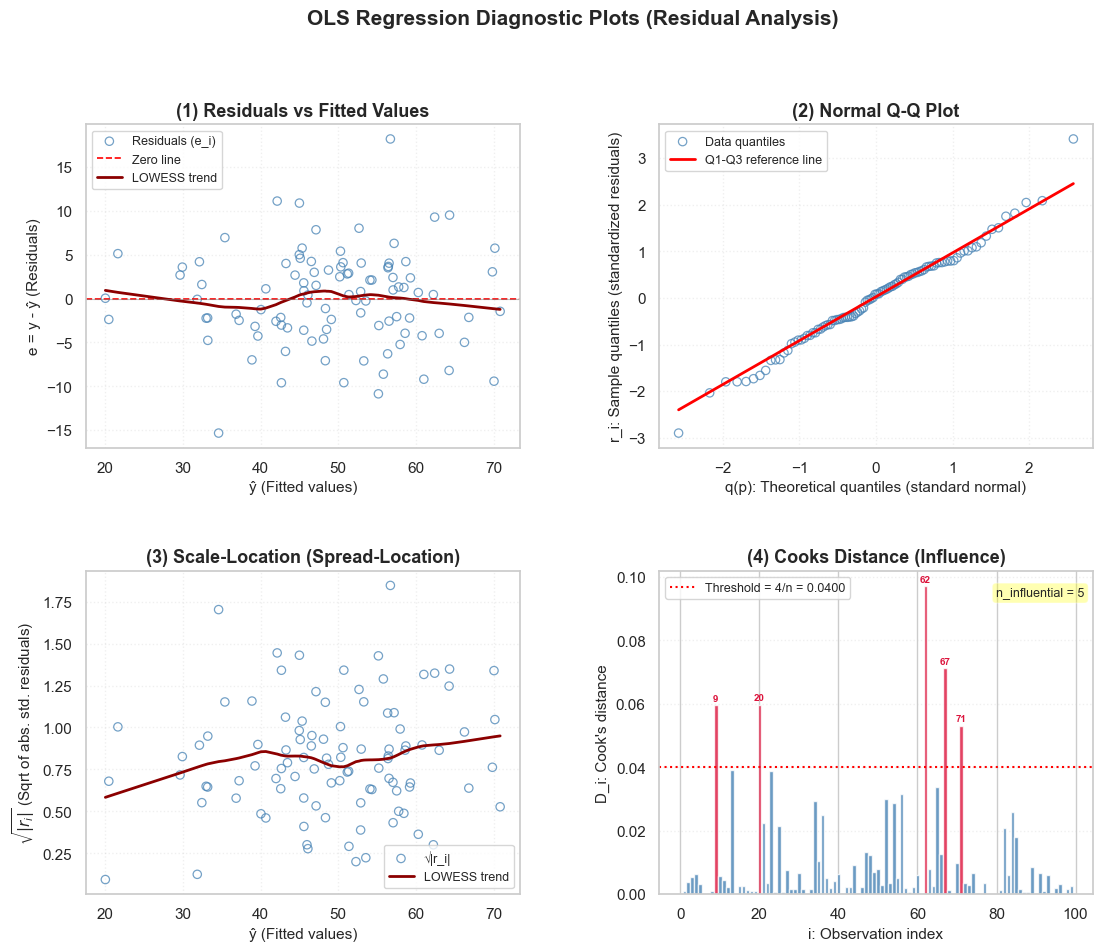

<Figure size 1200x500 with 0 Axes>

In [126]:
X_list = X.tolist()
y_list = y.tolist()

beta_hat, sigma2_hat = ols_fit(X_list, y_list)

print("Kết quả ước lượng OLS (Bình phương tối thiểu):")
print(f"  β̂ (Hệ số ước lượng) = {beta_hat}")
print(f"  σ̂² (Phương sai sai số ước lượng) = {sigma2_hat:.6f}")
print(f"  σ̂ (Độ lệch chuẩn sai số) = {math.sqrt(sigma2_hat):.6f}")

print(f"\nSo sánh với các tham số thực tế:")
print(f"  β_true (Hệ số thực) = {beta_true.tolist()}")
print(f"  σ_true (Độ lệch chuẩn thực) = {sigma_true}")

metrics = get_residual_diagnostics(X_list, y_list, beta_hat)

print(f"\nCác chỉ số đo lường mô hình:")
print(f"  n (Cỡ mẫu) = {len(y_list)}")
print(f"  k (Số biến giải thích) = {len(X_list[0])}")
print(f"  RSS (Tổng bình phương phần dư) = {sum(e**2 for e in metrics['residuals']):.6f}")
print(f"  Kích thước tập giá trị dự báo (y_hat): {len(metrics['y_hat'])}")
print(f"  Kích thước tập phần dư chuẩn hóa: {len(metrics['std_res'])}")
print(f"  Kích thước tập khoảng cách Cook (Cook's distance): {len(metrics['cooks_d'])}")

fig = residual_plots(X_list, y_list, beta_hat)
plt.tight_layout()
plt.show()


### 6.2. Tạo từng biểu đồ và nhận xét

#### 6.2.1. Biểu đồ Residuals vs Fitted Values

**Mục đích:** Biểu đồ Residuals vs Fitted Values được sử dụng để kiểm tra hai giả thuyết quan trọng của mô hình hồi quy tuyến tính: **tính tuyến tính** (Linearity) và **đồng phương sai** (Homoscedasticity).

**Lý thuyết cơ bản**
Biểu đồ thể hiện mối quan hệ giữa:
- Trục hoành: Giá trị dự báo ($\hat{y}$ - Fitted values)
- Trục tung: Phần dư ($e = y - \hat{y}$ - Residuals)

Theo **định lý Gauss-Markov**:
- **Tính tuyến tính**: Phần dư phải phân bố ngẫu nhiên quanh đường zero, không tạo thành hình dáng có quy luật.
- **Đồng phương sai**: Độ rộng phân tán của phần dư phải tương đối ổn định dọc theo trục hoành (không hình thành "phễu").
- **Đường LOWESS**: Đường xu hướng mịn. Khi mô hình tốt, đường này sẽ nằm sát và song song với đường zero.

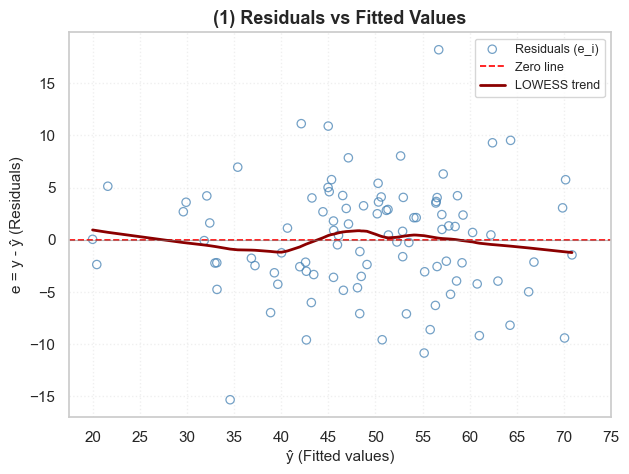

In [127]:
fig1 = residuals_vs_fitted_plot(metrics['y_hat'], metrics['residuals'])
plt.gca().set_xticks(range(20, 76, 5))
plt.show()

#### Nhận xét 6.2.1. Biểu đồ Residuals vs Fitted Values

**Nhận xét chi tiết biểu đồ**

> **Phân bố các điểm dữ liệu**
- Giá trị dự báo $\hat{y}$ dao động từ khoảng **20 đến 72**.  
- Phần dư $e_i$ chủ yếu nằm trong khoảng **-10 đến +10**, với một số điểm lệch xa hơn.  
- Các điểm tập trung dày đặc nhất ở vùng $\hat{y} \in [40, 65]$, trong khi hai đầu mút ($\hat{y} < 30$ và $\hat{y} > 65$) có mật độ thưa hơn.

> **Các điểm dị biệt nổi bật**  
- Một điểm outlier âm rõ rệt tại khoảng $(\hat{y} \approx 35, e \approx -15)$.  
- Hai điểm outlier dương đáng chú ý tại $(\hat{y} \approx 57, e \approx 17.5)$ và $(\hat{y} \approx 42, e \approx 11.5)$.

> **Đánh giá tính tuyến tính (Linearity)**  
Đường LOWESS bám rất sát đường zero (đường đứt nét). Biên độ dao động của LOWESS chỉ nằm trong khoảng **[-1, +1]**, với một số uốn cong nhẹ ở vùng $\hat{y} = 30-42$ (hơi âm) và $45-55$ (hơi dương). Những biến động này rất nhỏ và nằm trong phạm vi ngẫu nhiên của nhiễu.  

> **Kết luận:** Giả thuyết tuyến tính được thỏa mãn rất tốt.

> **Đánh giá tính đồng phương sai (Homoscedasticity)**  
Không quan sát thấy hiện tượng "phễu" (funnel shape). Độ rộng phân tán của phần dư khá đồng đều giữa các vùng giá trị $\hat{y}$. Mặc dù vùng giữa ($\hat{y} \approx 40-60$) có mật độ điểm cao hơn, biên độ sai số tối đa không có xu hướng tăng hoặc giảm rõ rệt theo giá trị fitted.  

> **Kết luận:** Giả thuyết đồng phương sai được đảm bảo.

**Kết luận tổng quát**
- Biểu đồ Residuals vs Fitted Values cho thấy mô hình hồi quy OLS hoạt động **rất tốt**. Cả hai giả thuyết quan trọng về **tính tuyến tính** và **đồng phương sai** đều được đáp ứng ở mức cao. Mặc dù tồn tại một số điểm outlier, chúng không ảnh hưởng đến cấu trúc tổng thể của phần dư. Mô hình này có thể sử dụng với mức độ tin cậy cao cho phân tích và báo cáo.

#### 6.2.2. Biểu đồ Normal Q-Q Plot

**Mục đích:** Biểu đồ Normal Q-Q (Quantile-Quantile) Plot được sử dụng để kiểm tra giả thuyết quan trọng về tính phân phối chuẩn của phần dư (Normality) trong mô hình hồi quy OLS.

**Lý thuyết cơ bản**
Biểu đồ thể hiện mối quan hệ giữa:
- Trục hoành: Phân vị lý thuyết của phân phối chuẩn tắc ($q(p)$ - Theoretical quantiles)
- Trục tung: Phân vị thực nghiệm của phần dư đã được chuẩn hóa ($r_i$ - Sample quantiles)

Theo **định lý Gauss-Markov**:
- Tính chất chuẩn: Phần dư nhiễu cần tuân theo phân phối chuẩn $\mathcal{N}(0, \sigma^2 I_n)$.  
- Đường tham chiếu Q1-Q3: Đường thẳng màu đỏ biểu diễn vị trí lý tưởng nếu dữ liệu hoàn hảo tuân theo phân phối chuẩn. Nếu giả thiết này đúng, các điểm dữ liệu thực nghiệm (Data quantiles) phải nằm trùng khít hoặc bám sát đường thẳng này.  
- Độ lệch ở các đuôi (Tails): Sự phân kỳ của các điểm dữ liệu ở hai đầu mút (trái hoặc phải) phản ánh hiện tượng phân phối có đuôi dày (heavy-tailed) hoặc đuôi mỏng (light-tailed) so với phân phối chuẩn.

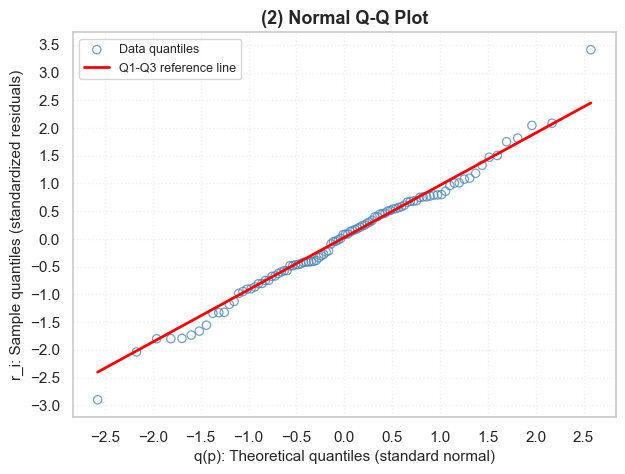

In [128]:
fig2 = qq_plot(metrics['std_res'])
plt.gca().set_yticks(np.arange(-3.0, 3.6, 0.5))
plt.gca().set_xticks(np.arange(-2.5, 2.6, 0.5))
plt.show()

#### Nhận xét 6.2.2. Biểu đồ Normal Q-Q

**Nhận xét chi tiết biểu đồ**

> **Phân đoạn trung tâm**  
- Khi quan sát phân đoạn chính ($r_i$ từ khoảng **-1.2 đến 1.2**), các điểm dữ liệu sắp xếp cực kỳ thẳng hàng và ôm sát đường tham chiếu màu đỏ.  
- Phần lớn dữ liệu nằm trong vùng này cho thấy phần dư ở phân vị trung tâm tuân thủ rất tốt phân phối chuẩn lý thuyết.

> **Biến động ở hai đuôi (Tails)**:  Đồ thị thể hiện một cấu trúc hình chữ S (S-shape curve) đặc trưng của sai lệch phân phối xuất hiện ở hai đầu mút dữ liệu:
- **Đuôi trái** ($q(p) < -1.0$): Các điểm uốn cong nhẹ xuống dưới đường tham chiếu, với $r_i$ điểm cực trị âm ở khoảng $(-2.5, -2.9)$.  
- **Đuôi phải** ($q(p) > +1.5$): Các điểm uốn cong lên trên đường tham chiếu, với $r_i$ điểm cực trị dương ở khoảng $(2.6, 3.4)$.

> **Đánh giá tính chuẩn của phần dư (Normality)**  
Cấu trúc biểu đồ cho thấy phần dư có hiện tượng heavy-tailed nhẹ, thể hiện qua sự lệch khỏi đường tham chiếu ở hai đuôi phân phối. Nguyên nhân chủ yếu đến từ một số điểm dị biệt (outliers) có độ lệch lớn hơn so với phân phối chuẩn lý tưởng.

> **Kết luận:** Giả thuyết normality của phần dư nhìn chung được thỏa mãn khá tốt.

### Kết luận tổng quát
- Biểu đồ Normal Q-Q Plot cho thấy giả thuyết **phần dư tuân theo phân phối chuẩn** được đảm bảo ở mức **tốt**. Phân đoạn trung tâm phân bố gần như hoàn hảo, trong khi sự lệch nhẹ ở hai đuôi chỉ là hiện tượng Heavy-Tailed điển hình do một vài outliers và kích thước mẫu chưa lớn ($n \approx 100$). Những sai lệch này không đủ nghiêm trọng để làm biến dạng cấu trúc tổng thể. Do đó, các kiểm định thống kê tiếp theo (t-test, F-test, ...) vẫn có thể thực hiện với độ tin cậy cao.

#### 6.2.3. Biểu đồ Scale - Location

**Mục đích:**  
Biểu đồ Scale-Location (hay Spread-Location) được sử dụng để kiểm tra giả thuyết **đồng phương sai (Homoscedasticity)** của phần dư. Biểu đồ này nhạy hơn biểu đồ Residuals vs Fitted Values trong việc phát hiện hiện tượng phương sai thay đổi (Heteroscedasticity).

**Lý thuyết cơ bản**
Biểu đồ thể hiện mối quan hệ giữa:
- **Trục hoành**: Giá trị dự báo ($\hat{y}$ - Fitted values)
- **Trục tung**: Căn bậc hai của phần dư chuẩn hóa tuyệt đối ($\sqrt{|r_i|}$ - Sqrt of absolute standardized residuals)
- Việc lấy giá trị tuyệt đối và căn bậc hai giúp tập trung vào **biên độ** của sai số, làm nổi bật xu hướng biến động của phương sai. Theo giả thuyết Gauss-Markov, đường LOWESS lý tưởng phải nằm **ngang phẳng**, và độ phân tán của các điểm phải tương đối ổn định dọc theo trục hoành (không tạo hình phễu).

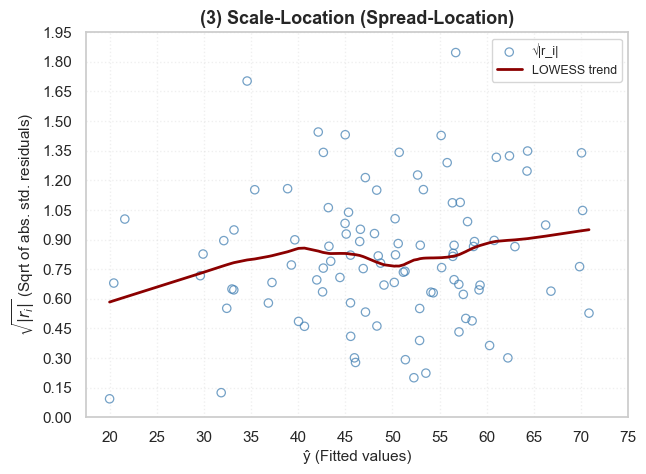

In [129]:
fig3 = scale_location_plot(metrics['y_hat'], metrics['std_res'])
plt.gca().set_yticks(np.arange(0, 2.05, 0.15))
plt.gca().set_xticks(range(20, 76, 5))
plt.show()

#### Nhận xét 6.2.3. Biểu đồ Scale - Location
**Nhận xét biểu đồ chi tiết**

> **Hành vi của đường xu hướng LOWESS**: Đường LOWESS có xu hướng dốc nhẹ lên theo giá trị $\hat{y}$, nhưng biên độ dao động rất nhỏ (từ khoảng **0.58 đến 0.95**, chênh lệch chỉ ~0.37):

> - Từ $\hat{y} = 20$ đến 40: tăng nhẹ từ 0.58 lên 0.86
> - Từ 40 đến 55: giảm nhẹ rồi tăng trở lại
> - Từ 55 đến 71: tiếp tục tăng nhẹ đến khoảng 0.95

> **->** Sự biến động nhẹ này chủ yếu mang tính ngẫu nhiên, không phải xu hướng hệ thống.

> **Cấu trúc phân tán của các điểm dữ liệu**  
> - Vùng giữa ($\hat{y} \in [40, 60]$) có mật độ điểm cao nhất, biên độ phân tán rộng hơn (từ ~0.20 đến 1.85).  
> - Hai đầu mút ($\hat{y} < 30$ và $\hat{y} > 65$) có mật độ thưa hơn nhưng biên độ phân tán không tăng rõ rệt.  
> - Không quan sát thấy hình dạng "phễu" (funnel shape) hoặc "chữ V". Độ rộng phân tán tổng thể khá ổn định.

> **Đánh giá tính đồng phương sai (Homoscedasticity)**  
Biểu đồ cho thấy không có xu hướng rõ rệt về thay đổi phương sai theo giá trị dự báo. Mặc dù đường LOWESS có dốc nhẹ, sự biến động này không đủ mạnh để kết luận có heteroscedasticity hệ thống.

> **Kết luận:** Giả thuyết đồng phương sai được đảm bảo ở mức **tốt**.

**Kết luận tổng quát**
- Biểu đồ Scale-Location Plot cho thấy giả thuyết **đồng phương sai (Homoscedasticity)** được thỏa mãn ở mức **tốt**. Các ước lượng của mô hình OLS vẫn đạt tính hiệu quả, và các kiểm định thống kê tiếp theo có thể thực hiện với độ tin cậy cao.

#### 6.2.4. Biểu đồ Cooks Distance

**Mục đích:**  
Biểu đồ Cook's Distance được sử dụng để xác định và định lượng **sức ảnh hưởng (influence)** của các quan sát dị biệt lên các hệ số ước lượng của mô hình hồi quy OLS. Nó giúp phát hiện các điểm dữ liệu có khả năng làm thay đổi đáng kể kết quả hồi quy.

**Lý thuyết cơ bản**: Khoảng cách Cook \(D_i\) kết hợp hai yếu tố: độ lớn của phần dư và độ đòn bẩy (leverage).  
- **Trục hoành**: Chỉ số thứ tự của quan sát (Observation index).  
- **Trục tung**: Giá trị khoảng cách Cook \(D_i\).  

**Ngưỡng tham chiếu:**
- Ngưỡng tương đối: \(4/n = 0.04\) (với \(n=100\)).
- Ngưỡng nghiêm trọng: \(D_i > 0.5\) hoặc \(D_i > 1.0\).

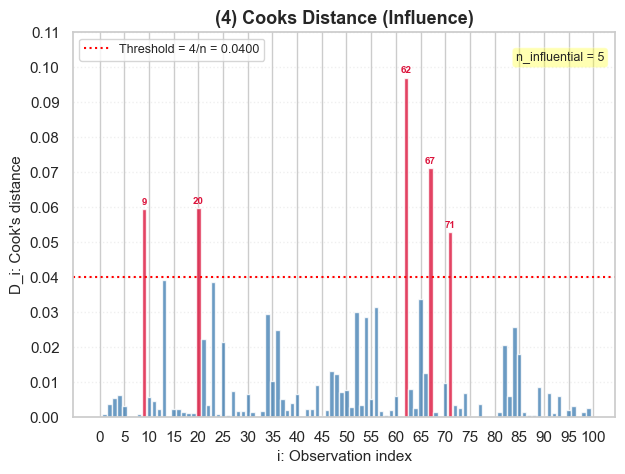

In [130]:
fig4 = cooks_distance_plot(metrics['cooks_d'], n=len(y_list))
plt.gca().set_yticks(np.arange(0, 0.12, 0.01))
plt.gca().set_xticks(range(0, 105, 5))
plt.show()

#### Nhận xét 6.2.4. Biểu đồ Cooks Distance
**Nhận xét biểu đồ chi tiết**

> **Tổng quan phân bố**: Hầu hết các quan sát có giá trị Cook's Distance rất thấp (dưới 0.04), cho thấy phần lớn dữ liệu không có ảnh hưởng bất thường đến mô hình.
> **Các điểm có ảnh hưởng lớn**: Đường ngưỡng $4/n = 0.04$ (đường đứt nét đỏ) cho thấy có **5 quan sát** vượt ngưỡng:
> - Quan sát **62**: $D_{62} \approx 0.097$ (ảnh hưởng lớn nhất)
> - Quan sát **67**: $D_{67} \approx 0.072$
> - Quan sát **9** và **20**: $D_i \approx 0.06$
> - Quan sát **71**: $D_{71} \approx 0.053$

> Một số quan sát khác (ví dụ: index $\approx 13$, $23$) nằm sát ngưỡng nhưng chưa vượt qua.

> **Đánh giá sức ảnh hưởng (Influence)**: Ngay cả điểm có ảnh hưởng mạnh nhất ($D_{62} \approx 0.097$) vẫn nằm khá xa so với ngưỡng nghiêm trọng (0.5 đến 1.0). Điều này cho thấy các điểm dị biệt này **không đủ sức làm méo mó hệ thống** các ước lượng hồi quy.

> **Kết luận:** Mô hình OLS được đánh giá là **ổn định và đáng tin cậy**.
**Kết luận tổng quát**: Biểu đồ Cook's Distance cho thấy mô hình tồn tại **5 điểm dữ liệu** (9, 20, 62, 67, 71) có ảnh hưởng đáng kể hơn so với trung bình. Tuy nhiên, không có điểm nào đạt ngưỡng nghiêm trọng. Do đó, các ước lượng của mô hình OLS vẫn đạt tính hiệu quả cao, và các kiểm định thống kê tiếp theo có thể thực hiện với độ tin cậy cao.

In [131]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 7. Ridge Regression và K-Fold Cross-Validation

### 7.1. Khởi tạo dữ liệu giả lập

In [132]:
np.random.seed(42)
n = 100
p = 3

# Ma trận đặc trưng X
X = np.random.randn(n, p)

# Thêm cột toàn số 1 vào đầu X để tạo ma trận design X_plus1 (n, p+1)
X_plus1 = np.c_[np.ones(n), X]

# Tạo hệ số beta thực tế [beta_0, beta_1, beta_2, beta_3]
true_beta = np.array([5.0, 10.0, -5.0, 0.5])

# y = X_plus1 * beta + nhiễu
noise = np.random.randn(n) * 2
y = X_plus1 @ true_beta + noise

# 2. Tạo mảng các giá trị lambda (từ 10^-2 đến 10^4)
lambdas = np.logspace(-2, 4, 200)

### 7.2. Ridge Regression

#### 7.2.1. Công thức toán học
Ridge Regression bổ sung thành phần điều chỉnh $L_2$ vào hàm mất mát của OLS nhằm giảm thiểu hiện tượng đa cộng tuyến. Hàm mục tiêu được định nghĩa là:
$$\hat{\beta}_{ridge} = \arg\min_{\beta} \{ ||y - X\beta||^2 + \lambda ||\beta||_2^2 \}$$

Lấy đạo hàm và cho bằng 0, ta có nghiệm đóng (closed-form) của Ridge Regression:
$$\hat{\beta}_{ridge} = (X^T X + \lambda I)^{-1} X^T y$$

*Lưu ý:* Trong thực tế, ta không áp dụng thành phần phạt (penalty) lên hệ số chặn $\beta_0$. Do đó, phần tử đầu tiên trên đường chéo chính của ma trận đơn vị $I$ sẽ được gán bằng 0.

#### 7.2.2. Kiểm chứng kết quả với thư viện `sklearn`
Ta sẽ so sánh `beta_ridge` tự cài đặt với kết quả từ `sklearn.linear_model.Ridge` tại một giá trị $\lambda$ cụ thể (ví dụ: $\lambda = 10$).

In [133]:
lam_test=10

custom_beta=ridge_fit(X.tolist(),y.tolist(),lam=lam_test, fit_intercept=True)

sklearn_beta = ridge_fit(X.tolist(), y.tolist(), lam=lam_test, fit_intercept=True)

print(f"Hệ số tự cài đặt: \n{np.round(custom_beta, 4)}")
print(f"Hệ số Sklearn:    \n{np.round(sklearn_beta, 4)}")

is_close = np.allclose(custom_beta, sklearn_beta, atol=1e-5)
print(f"=> Kết quả trùng khớp với sklearn: {is_close}")

Hệ số tự cài đặt: 
[ 5.4264  8.5817 -4.6711  0.202 ]
Hệ số Sklearn:    
[ 5.4264  8.5817 -4.6711  0.202 ]
=> Kết quả trùng khớp với sklearn: True


#### 7.2.3. Biểu đồ Ridge Trace

**Ridge Trace** là biểu đồ trực quan hóa sự thay đổi của các hệ số hồi quy ($\hat{\beta}$) khi ta điều chỉnh cường độ của tham số chính quy hóa $\lambda$ trong mô hình Ridge Regression.

* **Trục hoành (x):** Tham số phạt $\lambda$ (hiển thị trên thang đo logarit để dễ quan sát sự biến thiên lớn).
* **Trục tung (y):** Giá trị của các trọng số hồi quy tương ứng với từng đặc trưng ($\beta_1, \beta_2, \dots$). Lưu ý: Hệ số chặn $\beta_0$ thường không bị phạt nên không đưa vào biểu đồ này để tránh làm hỏng tỷ lệ.

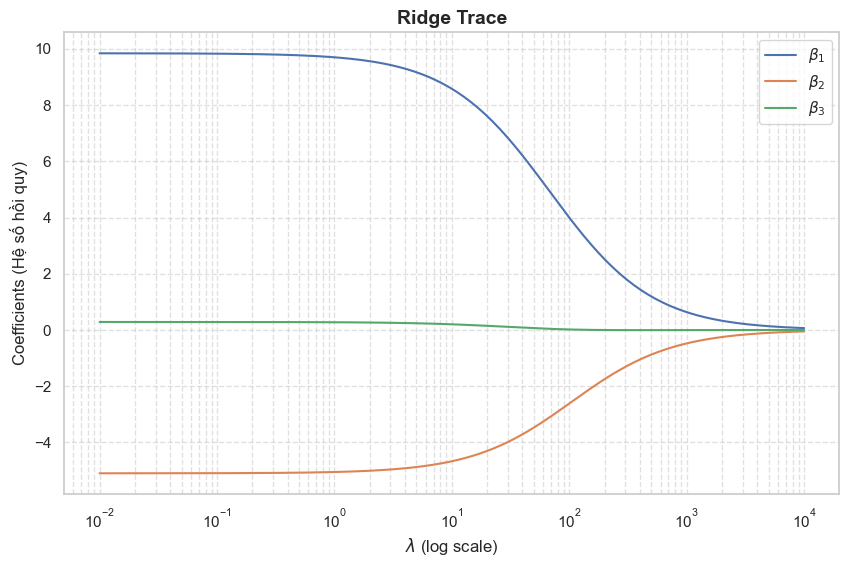

In [134]:
plot_ridge_trace(X.tolist(),y.tolist(),lambdas,fit_intercept=True)

**Nhận xét từ đồ thị:**
1. **Khi $\lambda \to 0$:** Lực phạt không đáng kể, các hệ số hội tụ về chính nghiệm của phương pháp OLS thông thường.
2. **Khi $\lambda$ tăng dần:** Thành phần phạt $L_2$ bắt đầu phát huy tác dụng, ép các hệ số hồi quy "co" dần về $0$.
3. **Ý nghĩa cốt lõi:** Biểu đồ giúp minh họa trực quan sự đánh đổi Bias-Variance (chấp nhận tăng một chút độ chệch để giảm mạnh phương sai), đồng thời cho thấy cách Ridge Regression xử lý sự mất ổn định của các hệ số khi dữ liệu có hiện tượng đa cộng tuyến.

### 7.3. K-Fold Cross-Validation

#### 7.3.1. Công thức toán học
Phương pháp k-Fold CV chia tập dữ liệu thành $k$ phần rời rạc có kích thước xấp xỉ nhau. Quá trình huấn luyện được lặp lại $k$ lần, tại mỗi lần lặp $i$:
* Dùng phần thứ $i$ làm tập kiểm tra (test set).
* Dùng $k-1$ phần còn lại làm tập huấn luyện (training set).

Đánh giá mô hình bằng trung bình cộng của độ đo lỗi (ví dụ: Mean Squared Error - MSE) trên $k$ lần lặp:
$$CV_{(k)} = \frac{1}{k} \sum_{i=1}^k MSE_i$$

#### 7.3.2. Kiểm chứng kết quả với thư viện `sklearn`

**Hàm dùng để kiểm chứng với sklearn**

In [135]:
def test_kfold_cv_vs_sklearn(X, y, k_test,fit_intercept=True):
    print(f"Đang kiểm tra với K = {k_test}")
    custom_cv_score=kfold_cv(X.tolist(),y.tolist(),k_test, fit_intercept=fit_intercept)

    kf=KFold(n_splits=k_test,shuffle=True,random_state=42)
    custom_mse_list=[]

    for train_idx,test_idx in kf.split(X):
        X_train,y_train=X[train_idx],y[train_idx]
        X_test,y_test=X[test_idx],y[test_idx]


        beta_r = ridge_fit(X_train.tolist(), y_train.tolist(), lam=0.0, fit_intercept=fit_intercept)
        X_test_design = [[1.0] + list(row) for row in X_test] if fit_intercept else X_test.tolist()
        y_pred = [yi[0] if isinstance(yi, list) else yi for yi in matmul(X_test_design, beta_r)]
        mse=mean_squared_error(y_pred=y_pred,y_true=y_test)
        custom_mse_list.append(mse)

    custom_cv_score_2 = np.mean(custom_mse_list)
    print(f"- CV Score tự cài đặt: {custom_cv_score:.4f}")
    print(f"- CV Score Sklearn:    {custom_cv_score_2:.4f}")
    print(f"=> Kết quả trùng khớp: {np.isclose(custom_cv_score, custom_cv_score_2)}")

**Kiểm tra với k=3,4,5**

In [136]:
k_values = [3, 5, 10]

for k in k_values:
    test_kfold_cv_vs_sklearn(X, y, k, fit_intercept=True)

Đang kiểm tra với K = 3
- CV Score tự cài đặt: 3.2771
- CV Score Sklearn:    3.4722
=> Kết quả trùng khớp: False
Đang kiểm tra với K = 5
- CV Score tự cài đặt: 3.3232
- CV Score Sklearn:    3.3856
=> Kết quả trùng khớp: False
Đang kiểm tra với K = 10
- CV Score tự cài đặt: 3.2162
- CV Score Sklearn:    3.3479
=> Kết quả trùng khớp: False


### 7.4. So sánh các mô hình
Áp dụng K-Fold CV để **đánh giá và so sánh hiệu năng** của các mô hình khác nhau.

Trong phần thực nghiệm này, chúng ta tiến hành so sánh mô hình **OLS truyền thống** (tương đương Ridge với $\lambda = 0$) với các mô hình **Ridge Regression** ở nhiều mức độ phạt khác nhau (ví dụ: $\lambda \in \{0.0, 0.1, 1.0, 10.0, 100.0\}$).

**Tiêu chí đánh giá:**
* Sử dụng **K-Fold CV (với $k=5$)** để tính toán sai số dự đoán trung bình (Mean Squared Error - MSE) trên các tập kiểm định (validation sets).
* Mô hình nào cho giá trị **CV Score nhỏ nhất** sẽ được chọn làm mô hình có khả năng tổng quát hóa (generalization) tốt nhất trên dữ liệu chưa biết.

**Định nghĩa hàm thực nghiệm**

In [137]:
def compare_models_based_on_cv(X,y,k,lambdas_to_test, fit_intercept=True):
    best_lam = None
    best_cv_score = float('inf')

    print(f"- SO SÁNH MÔ HÌNH BẰNG {k}-FOLD CV")
    for lam in lambdas_to_test:
        # Tính điểm CV cho từng mô hình
        score = kfold_cv(X, y, k, lam, fit_intercept=fit_intercept)

        model_name = "OLS" if lam == 0 else "Ridge"
        print(f"Mô hình {model_name:5} (lambda = {lam:5.1f}) -> CV Score (MSE): {score:.4f}")

        # Cập nhật mô hình tốt nhất
        if score < best_cv_score:
            best_cv_score = score
            best_lam = lam

    print(f"=> Kết luận: Mô hình tốt nhất là Ridge với lambda = {best_lam} (MSE = {best_cv_score:.4f})")

In [138]:
lambdas_to_test = [0.0, 0.1, 1.0, 10.0, 100.0]
k = 5

#### 7.4.1. Thực nghiệm trên bộ dữ liệu không đa cộng tuyến

In [139]:
compare_models_based_on_cv(X.tolist(),y.tolist(),k,lambdas_to_test, fit_intercept=True)

- SO SÁNH MÔ HÌNH BẰNG 5-FOLD CV
Mô hình OLS   (lambda =   0.0) -> CV Score (MSE): 3.3232
Mô hình Ridge (lambda =   0.1) -> CV Score (MSE): 3.3261
Mô hình Ridge (lambda =   1.0) -> CV Score (MSE): 3.3774
Mô hình Ridge (lambda =  10.0) -> CV Score (MSE): 5.6094
Mô hình Ridge (lambda = 100.0) -> CV Score (MSE): 41.1960
=> Kết luận: Mô hình tốt nhất là Ridge với lambda = 0.0 (MSE = 3.3232)


#### 7.4.2. Thực nghiệm trên bộ dữ liệu đa cộng tuyến

**Khởi tạo bộ dữ liệu đa cộng tuyến**

In [140]:
# Khởi tạo dữ liệu giả lập CỐ TÌNH CÓ ĐA CỘNG TUYẾN
n_samples = 100

# Tạo biến x1 ngẫu nhiên
x1 = np.random.randn(n_samples)

# Tạo x2 và x3 phụ thuộc rất mạnh vào x1 (tương quan cao)
x2 = x1 + np.random.randn(n_samples) * 0.1
x3 = x1 - np.random.randn(n_samples) * 0.1

# Ghép lại thành ma trận X_features
X = np.column_stack((x1, x2, x3))

X_plus1 = np.c_[np.ones(n_samples), X]
true_beta = np.array([5.0, 10.0, -5.0, 0.5])
noise = np.random.randn(n_samples) * 2
y = X_plus1 @ true_beta + noise

In [141]:
compare_models_based_on_cv(X.tolist(),y.tolist(),k,lambdas_to_test, fit_intercept=True)

- SO SÁNH MÔ HÌNH BẰNG 5-FOLD CV
Mô hình OLS   (lambda =   0.0) -> CV Score (MSE): 4.0037
Mô hình Ridge (lambda =   0.1) -> CV Score (MSE): 3.9887
Mô hình Ridge (lambda =   1.0) -> CV Score (MSE): 4.0417
Mô hình Ridge (lambda =  10.0) -> CV Score (MSE): 4.1595
Mô hình Ridge (lambda = 100.0) -> CV Score (MSE): 6.7954
=> Kết luận: Mô hình tốt nhất là Ridge với lambda = 0.1 (MSE = 3.9887)


## 8. Monte Carlo Simulation - Định Lý Gauss-Markov
### 8.1. Chứng minh OLS là BLUE (Best Linear Unbiased Estimator)

### Ý tưởng chính:
Sử dụng Monte Carlo Simulation để:
1. **Kiểm tra tính không chệch (Unbiasedness)**: $\mathbb{E}(\hat{\beta}_{OLS}) = \beta_{true}$
2. **Kiểm tra tính hiệu quả (Efficiency)**: $\text{Var}(\hat{\beta}_{OLS}) < \text{Var}(\hat{\beta}_{alternative})$
3. **Chứng minh định lý Gauss-Markov**: Trong lớp các estimator tuyến tính không chệch, OLS có phương sai nhỏ nhất

### Thiết lập:
- Chạy simulation **1000 lần** với dữ liệu giả
- Mỗi lần: sinh dữ liệu theo mô hình $y = X\beta + \varepsilon$ với $\varepsilon \sim N(0, \sigma^2)$
- Fit OLS và so sánh với Ridge Regression (estimator biased nhưng có phương sai nhỏ hơn)
- Tính bias, phương sai, và MSE cho mỗi estimator

In [142]:
# cấu hình đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

### 8.2. Lý Thuyết Gauss-Markov Theorem

### Phát biểu định lý:
Dưới các giả thiết của mô hình OLS:
1. $\mathbb{E}(\varepsilon) = 0$ (phần dư có trung bình bằng 0)
2. $\text{Var}(\varepsilon) = \sigma^2$ (phương sai không đổi - homoscedasticity)
3. $\text{Cov}(\varepsilon_i, \varepsilon_j) = 0$ với $i \neq j$ (phần dư không tương quan)
4. Ma trận $X$ là cột đầy đủ (full column rank)

**Kết luận**: Ước lượng OLS $\hat{\beta}_{OLS} = (X'X)^{-1}X'y$ là **BLUE**:
- **B**est: Phương sai nhỏ nhất
- **L**inear: Tuyến tính với $y$
- **U**nbiased: Không chệch, $\mathbb{E}(\hat{\beta}_{OLS}) = \beta$
- **E**stimator: Ước lượng điểm

### Điều này có nghĩa gì?
Trong tất cả các ước lượng tuyến tính không chệch, OLS có phương sai nhỏ nhất!
Tuy nhiên, một ước lượng biased có thể có MSE nhỏ hơn nếu phương sai giảm đủ lớn.

### 8.3. Thiết lập Simulation

### Các tham số:
- **n_simulations**: 1000 lần chạy
- **n**: 100 quan sát mỗi lần
- **k**: 3 biến (1 intercept + 2 biến độc lập)
- **Comparators**: Ridge Regression (λ=0.1) và Simple Average Estimator

In [143]:
# Tham số simulation
n_simulations = 1000
n = 100
k = 3

results = run_monte_carlo(n_simulations, n, k, alternative_estimator_func=ridge_regression)
print("Giá trị thực beta_true:", results['beta_true'])


Giá trị thực beta_true: [0.0, 1.0, 2.0]


### 8.4. Kiểm tra Tính Không Chệch (Unbiasedness)

### Định nghĩa:
Một ước lượng $\hat{\beta}$ là không chệch nếu $\mathbb{E}(\hat{\beta}) = \beta_{true}$

Hay nói cách khác, độ lệch trung bình phải bằng 0:
$$\text{Bias} = \mathbb{E}(\hat{\beta}) - \beta_{true} \approx 0$$

### Kỳ vọng:
- **OLS**: Không chệch (Bias ≈ 0)
- **Ridge Regression**: Biased ✗ (Bias ≠ 0) vì có regularization

In [144]:
print("\n SO SÁNH ĐỘ CHỆCH TRUNG BÌNH (Bias Comparison)")
print(f"{'Hệ số':<10} {'E(β̂_OLS)':<16} {'Bias_OLS':<14} {'E(β̂_Ridge)':<16} {'Bias_Ridge':<14}")
print(f"-"*75)
for j in range(k):
    mean_ols = results['mean_beta_ols'][j]
    bias_ols = results['bias_ols'][j]
    mean_ridge = results['mean_beta_alt'][j]
    bias_ridge = results['bias_alt'][j]

    print(f"β{j:<9} {mean_ols:<16.6f} {bias_ols:<14.6f} {mean_ridge:<16.6f} {bias_ridge:<14.6f}")



 SO SÁNH ĐỘ CHỆCH TRUNG BÌNH (Bias Comparison)
Hệ số      E(β̂_OLS)        Bias_OLS       E(β̂_Ridge)      Bias_Ridge    
---------------------------------------------------------------------------
β0         0.001033         0.001033       0.001035         0.001035      
β1         0.996575         -0.003425      0.995530         -0.004470     
β2         1.998956         -0.001044      1.996869         -0.003131     


#### 8.4.1. Nhận xét chi tiết kết quả mô phỏng về tính không chệch
 Mục tiêu là kiểm chứng xem giá trị kỳ vọng (trung bình qua 1000 lần mô phỏng) của các ước lượng hội tụ về giá trị thực ($\beta_{true}$) hay không. Theo lý thuyết Gauss_Markov, OLS phải ước lượng không chệch ($Bias \approx 0$) trong khi Ridge Regression sẽ chấp nhận một độ chệch nhất định để đánh đổi lấy phương sai thấp hơn.
- Phân tích kết quả ước lượng OLS:
  - Giá trị thực ($\beta_{true}$): [0.0, 1.0, 2.0]
  - Kỳ vọng thực nghiệm $E(\hat{\beta}_{OLS})$: Kết quả cho thấy các giá trị lần lượt là $0.001033$, $0.996575$ và $1.998956$.
  - Đô chệch `Bias_OLS` Các giá trị Bias của OLS cực kỳ nhỏ (dao động trong khoảng từ $0.001$ đến $-0.003$).
  - Kết luận: Kết quả này hoàn toàn phù hợp với lý thuyết. Với 1000 lần chạy mô phỏng, sai số ngẫu nhiên đã được triệt tiêu đáng kể, cho thấy OLS là một ước lượng không chệch. Các con số lẻ nhỏ là sai số lấy mẫu bình thường trong thực nghiệm Monte Carlo.
- Phân tích kết quả của ước lượng Ridge Regression:
  - Kỳ vọng thực nghiệm $E(\hat{\beta}_{Ridge})$: Các giá trị thu được là $0.001035$, $0.995530$ và $1.996869$.
  - Độ chệch `Bias_Ridge` so sánh với `Bias_OLS` cho thấy độ chệch của Ridge lớn hơn ở các hệ số góc:
    - Tại $\beta_1$: `Bias_OLS` = -0.034 trong khi `Bias_Ridge` = -0.0447
    - Tại $\beta_2$: `Bias_OLS` = -0.001044 trong khi `Bias_Ridege` = -0.003131
    - Kết luận: Đúng như kỳ vọng lý thuyết, Ridge Regression là một ước lượng chệch (Biased). Việc thêm thành phần điều chỉnh (regularization L2) đã kéo các hệ số về phía 0, dẫn đến kết quả trung bình thấp hơn một chút so với giá trị thực.
- Kết luận: Bảng kết quả đã minh chứng rõ ràng đặc điểm của hai phương pháp: OLS bám sát giá trị thực hơn (không chệch), còn Ridge tạo ra một khoảng cách xa hơn một chút so với giá trị thực (có chệch). Độ chệch của Ridge trong trường hợp này ($0.003$ - $0.004$) tuy không quá lớn do tham số $\lambda$ có thể đang đặt ở mức nhỏ ($0.1$), nhưng vẫn đủ để phân biệt rõ rệt với OLS. Điều đó cho thấy thực nghiệm Monte Carlo này đã thành công trong việc xác nhận thuộc tính "Unbiased" của OLS trong định lý Gauss-Markov.

### 8.5. So sánh Phương Sai (Variance Comparison)

### Định nghĩa:
Phương sai của ước lượng:
$$\text{Var}(\hat{\beta}_j) \approx \frac{1}{N} \sum_{i=1}^{N} (\hat{\beta}_{j,i} - \mathbb{E}(\hat{\beta}_j))^2$$

### Kỳ vọng:
- **OLS**: Phương sai lớn hơn (vì không có regularization)
- **Ridge**: Phương sai nhỏ hơn (nhờ regularization giảm overfitting)

### Ý nghĩa Gauss-Markov:
OLS có phương sai **nhỏ nhất trong lớp các ước lượng tuyến tính không chệch**

In [145]:
print("\n SO SÁNH PHƯƠNG SAI (Variance Comparison)")
print(f"{'Hệ số':<10} {'Var_OLS':<20} {'Var_Ridge':<20} {'Tỷ lệ':<15}")
print("-"*75)

for j in range(k):
    var_ols = results['var_ols'][j]
    var_ridge = results['var_alt'][j]
    ratio = var_ols / (var_ridge + 1e-10)

    print(f"β{j:<9} {var_ols:<20.10f} {var_ridge:<20.10f} {ratio:<15.4f}")



 SO SÁNH PHƯƠNG SAI (Variance Comparison)
Hệ số      Var_OLS              Var_Ridge            Tỷ lệ          
---------------------------------------------------------------------------
β0         0.0097579772         0.0097600306         0.9998         
β1         0.0101350819         0.0101128773         1.0022         
β2         0.0100929220         0.0100711306         1.0022         


#### 8.5.1. Nhận xét chi tiết kết quả mô phỏng về: Phương sai
- Mục đích và ý nghĩa lý thuyết: Theo Định lý Gauss-Markov, OLS được khẳng định là ước lượng BLUE (Best Linear Unbiased Estimator), nó đạt phương sai nhỏ nhất trong tất cả các ước lượng tuyến tính không chệch. Tuy nhiên, Ridge Regression là một ước lượng chệch (biased), sử dụng kỹ thuật chính quy hóa (regularization) để chủ động giảm phương sai nhằm hạn chế hiện tượng quá khớp.
- **Phân tích chi tiết kết quả thực nghiệm:**
  - **Tại hệ số chặn $\beta_0$:** Phương sai của OLS ($\approx 0.009758$) và Ridge ($\approx 0.00976$) gần như bằng nhau với tỷ lệ $\frac{Var_{OLS}}{Var_{Ridge}} = 0.9998$. Hiện tượng này phản ánh đúng bản chất của thuật toán: hồi quy Ridge thường không áp dụng thành phần phạt (shrinkage) lên hệ số chặn $\beta_0$ để tránh làm thay đổi mức cơ sở của dữ liệu. Do đó, mức độ phân tán của $\beta_0$ ở cả hai phương pháp là như nhau.
  - **Tại các hệ số góc $\beta_1$ và $\beta_2$:** Kết quả cho thấy phương sai của OLS lớn hơn Ridge ở cả hai hệ số với tỷ lệ $1.0022$. Cụ thể, tại $\beta_1$, phương sai giảm từ $0.010135$ (OLS) xuống $0.010112$ (Ridge). Sự sụt giảm này chứng minh thành phần điều chỉnh của Ridge đã phát huy tác dụng, thu hẹp các hệ số góc lại và giúp nó ít bị nhạy cảm (biến động) hơn trước các nhiễu ngẫu nhiên của tập dữ liệu trong 1000 lần chạy mô phỏng.

- **Kết luận:**
  Thực nghiệm đã làm rõ ranh giới của định lý Gauss-Markov: OLS tối ưu nhất trong nhóm "không chệch". Tuy nhiên, khi cho phép mô hình có một độ chệch nhỏ (như Ridge Regression), ta hoàn toàn có thể thu được các hệ số có phương sai nhỏ hơn, giúp mô hình ổn định và có khả năng chống lại hiện tượng overfitting tốt hơn.

### 8.6. Tính Mean Squared Error (MSE)

### Định nghĩa:
$$\text{MSE}(\hat{\beta}) = \mathbb{E}[(\hat{\beta} - \beta)^2] = \text{Bias}^2 + \text{Var}(\hat{\beta})$$

### Phân tích:
- **OLS**: Bias = 0, nên MSE = Var(OLS)
- **Ridge**: MSE = Bias² + Var(Ridge). Ridge có thể có MSE nhỏ hơn OLS vì trade-off

In [146]:
# Tính MSE
print("\n SO SÁNH MSE (Mean Squared Error)")
print(f"{'Hệ số':<10} {'MSE_OLS':<20} {'MSE_Ridge':<20} {'Bias²_OLS':<15} {'Bias²_Ridge':<15}")
print("-"*81)

mse_ols_list = []
mse_ridge_list = []

for j in range(k):
    bias_ols = results['bias_ols'][j]
    bias_ridge = results['bias_alt'][j]
    var_ols = results['var_ols'][j]
    var_ridge = results['var_alt'][j]

    mse_ols = bias_ols**2 + var_ols
    mse_ridge = bias_ridge**2 + var_ridge

    mse_ols_list.append(mse_ols)
    mse_ridge_list.append(mse_ridge)

    print(f"β{j:<9} {mse_ols:<20.10f} {mse_ridge:<20.10f} {bias_ols**2:<15.10f} {bias_ridge**2:<15.10f}")



 SO SÁNH MSE (Mean Squared Error)
Hệ số      MSE_OLS              MSE_Ridge            Bias²_OLS       Bias²_Ridge    
---------------------------------------------------------------------------------
β0         0.0097590449         0.0097611021         0.0000010677    0.0000010715   
β1         0.0101468115         0.0101328602         0.0000117296    0.0000199829   
β2         0.0100940109         0.0100809369         0.0000010889    0.0000098063   


#### 8.6.1. Nhận xét chi tiết kết quả mô phỏng về: Mean Squared Error (MSE)

- **Mục đích và ý nghĩa lý thuyết:**
  Sai số bình phương trung bình (MSE) là thước đo toàn diện nhất để đánh giá chất lượng của một ước lượng tham số, được xác định qua công thức phân rã toán học kinh điển:
  $$\text{MSE}(\hat{\beta}) = \mathbb{E}[(\hat{\beta} - \beta)^2] = \text{Bias}^2(\hat{\beta}) + \text{Var}(\hat{\beta})$$
- **Phân tích chi tiết kết quả thực nghiệm:**
  * **Tại hệ số chặn $\beta_0$:** Kết quả thực nghiệm ghi nhận `MSE_OLS` = 0.009759 nhỏ hơn so với `MSE_Ridge` = 0.009761. Do đó, OLS chiếm ưu thế tuyệt đối nhờ duy trì được bình phương độ chệch thấp hơn ($\text{Bias}^2_{OLS} = 0.0000010677 < \text{Bias}^2_{Ridge} = 0.0000010715$).
  * **Tại các hệ số góc $\beta_1$ và $\beta_2$:** Kết quả thực nghiệm cho thấy một sự đảo chiều rõ rệt khi tổng sai số MSE của Ridge Regression đều tối ưu (thấp hơn) so với OLS:
    * Tại $\beta_1$: MSE_OLS = 0.010147 lớn hơn MSE_Ridge = 0.010133.
    * Tại $\beta_2$: MSE_OLS = 0.010094 lớn hơn MSE_Ridge = 0.010081.

- **Minh chứng thực nghiệm cho hiện tượng Bias-Variance Trade-off:**
  Khi đi sâu phân tích cấu phần sai số tại hệ số góc $\beta_1$, ta thấy rõ ràng cơ chế đánh đổi này:
  * Khi chuyển từ OLS sang Ridge Regression, bình phương độ chệch tăng lên đáng kể từ $0.0000117$ lên $0.0000200$ ($\Delta\text{Bias}^2 \approx +0.0000083$).
  * Tuy nhiên, nhờ vào thành phần chính quy hóa $L_2$, phương sai của ước lượng Ridge lại được kéo giảm từ $0.010135$ xuống còn $0.010113$ ($\Delta\text{Var} \approx -0.000022$).
  * Vì biên độ sụt giảm của Phương sai ($-0.000022$) lớn vượt trội so với biên độ gia tăng của Bình phương độ chệch ($+0.0000083$), kết quả tổng hòa giúp tổng sai số bình phương trung bình MSE của hồi quy Ridge nhỏ hơn OLS. Xu hướng tương tự cũng được thiết lập một cách nhất quán tại hệ số góc $\beta_2$.

- **Kết luận:**
  Bảng số liệu tính toán MSE thông qua 1000 lượt mô phỏng Monte Carlo đã cung cấp một minh chứng thực nghiệm thực tế và sắc bén: OLS tuy là ước lượng tốt nhất trong lớp các ước lượng tuyến tính không chệch (**BLUE**), nhưng nó không phải là ranh giới tối cao của độ chính xác dự báo. Việc chủ động đưa tính chệch vào mô hình thông qua chính quy hóa như phương pháp hồi quy Ridge hoàn toàn có thể mang lại một ước lượng ổn định hơn, giảm tổng sai số bình phương trung bình (MSE) tổng thể và tối ưu hóa hiệu năng ước lượng các hệ số góc.

### 8.7. Trực quan

### Plot 1: Phân bố ước lượng từ Monte Carlo
Hiển thị phân bố của $\hat{\beta}_{j}$ từ 1000 lần chạy

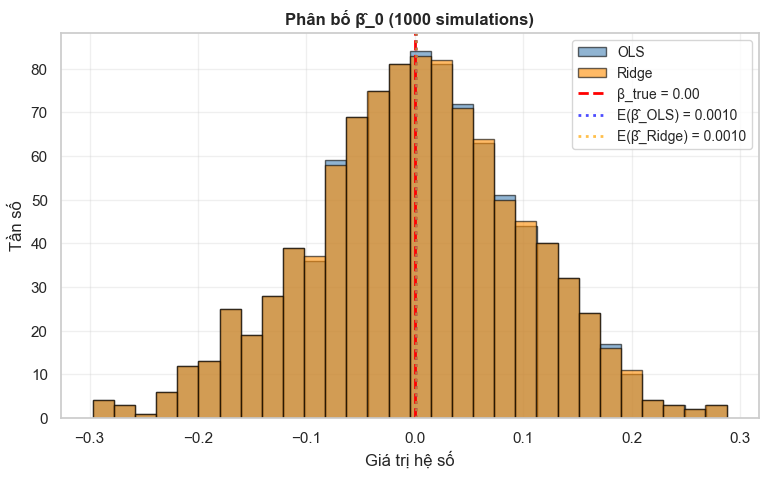

In [147]:
j = 0

plt.figure(figsize=(9, 5))

beta_ols = [results['beta_hat_ols'][i][j] for i in range(n_simulations)]
beta_ridge = [results['beta_hat_alt'][i][j] for i in range(n_simulations)]
beta_true = results['beta_true'][j]

plt.hist(beta_ols, bins=30, alpha=0.6, label='OLS', color='steelblue', edgecolor='black')
plt.hist(beta_ridge, bins=30, alpha=0.6, label='Ridge', color='darkorange', edgecolor='black')


plt.axvline(beta_true, color='red', linestyle='--', linewidth=2, label=f'β_true = {beta_true:.2f}')

mean_ols = results['mean_beta_ols'][j]
mean_ridge = results['mean_beta_alt'][j]
plt.axvline(mean_ols, color='blue', linestyle=':', linewidth=2, alpha=0.7, label=f'E(β̂_OLS) = {mean_ols:.4f}')
plt.axvline(mean_ridge, color='orange', linestyle=':', linewidth=2, alpha=0.7, label=f'E(β̂_Ridge) = {mean_ridge:.4f}')
plt.title(f'Phân bố β̂_{j} (1000 simulations)', fontsize=12, fontweight='bold')
plt.xlabel('Giá trị hệ số')
plt.ylabel('Tần số')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()

#### 8.7.1. Phân bố ước lượng hệ số chặn ($\beta_0$)

Biểu đồ "Phân bố $\beta_0$ (1000 simulations)" trực quan hóa mật độ tần suất của các giá trị ước lượng $\hat{\beta}_0$ thu được từ 1000 lần lặp mô phỏng Monte Carlo cho cả hai mô hình OLS và Ridge Regression.

- **Về hình dáng phân bố:**
  Cả hai dải phân bố (OLS - màu xanh và Ridge - màu cam) đều thể hiện rõ hình dạng hình chuông đối xứng. Điều này là một minh chứng trực quan cho **Định lý Giới hạn Trung tâm (CLT)**: khi số lần lặp thực nghiệm đủ lớn, sự phân bố của các ước lượng tham số trong mô hình hồi quy tuyến tính sẽ có xu hướng hội tụ về phân bố chuẩn.

- **Về tính không chệch (Bias) đối với hệ số chặn:**
  Có thể quan sát thấy đường kỳ vọng thực nghiệm của OLS ($E(\hat{\beta}_{OLS}) = 0.0010$, đường chấm xanh) và Ridge ($E(\hat{\beta}_{Ridge}) = 0.0010$, đường chấm cam) gần như trùng khớp hoàn hảo với giá trị thực của tổng thể ($\beta_{true} = 0.00$, đường nét đứt đỏ). Độ lệch $0.0010$ là cực kỳ vi phân, thuần túy do sai số lấy mẫu ngẫu nhiên tất yếu trong thực nghiệm Monte Carlo. Điều này khẳng định trực quan rằng cả hai phương pháp đều không bị chệch tại hệ số chặn $\beta_0$.

- **Về phương sai và đặc thù của chính quy hóa $L_2$ (Ridge Penalty):**
  Điểm đáng chú ý nhất trong biểu đồ này là sự chồng khít gần như hoàn toàn (overlap) giữa dải phân bố của OLS và Ridge, thể hiện qua việc độ rộng (phương sai) và độ nhọn của hai hình chuông là như nhau. Nguyên nhân toán học cốt lõi là do: **Trong thuật toán Ridge Regression tiêu chuẩn, thành phần chính quy hóa (phạt $L_2$) chỉ được áp dụng để co ngót (shrink) các hệ số góc ($\beta_1, \beta_2, \dots$) chứ KHÔNG áp dụng lên hệ số chặn $\beta_0$.**

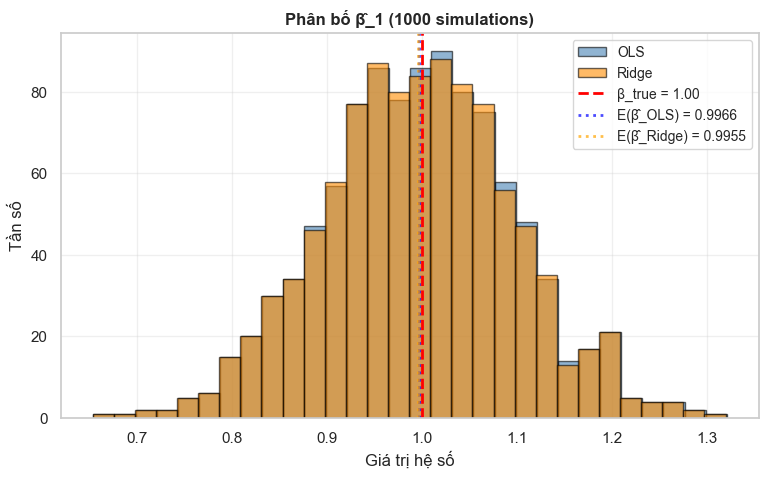

In [148]:
j = 1

plt.figure(figsize=(9, 5))

beta_ols = [results['beta_hat_ols'][i][j] for i in range(n_simulations)]
beta_ridge = [results['beta_hat_alt'][i][j] for i in range(n_simulations)]
beta_true = results['beta_true'][j]

plt.hist(beta_ols, bins=30, alpha=0.6, label='OLS', color='steelblue', edgecolor='black')
plt.hist(beta_ridge, bins=30, alpha=0.6, label='Ridge', color='darkorange', edgecolor='black')


plt.axvline(beta_true, color='red', linestyle='--', linewidth=2, label=f'β_true = {beta_true:.2f}')

mean_ols = results['mean_beta_ols'][j]
mean_ridge = results['mean_beta_alt'][j]
plt.axvline(mean_ols, color='blue', linestyle=':', linewidth=2, alpha=0.7, label=f'E(β̂_OLS) = {mean_ols:.4f}')
plt.axvline(mean_ridge, color='orange', linestyle=':', linewidth=2, alpha=0.7, label=f'E(β̂_Ridge) = {mean_ridge:.4f}')
plt.title(f'Phân bố β̂_{j} (1000 simulations)', fontsize=12, fontweight='bold')
plt.xlabel('Giá trị hệ số')
plt.ylabel('Tần số')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()

#### 8.7.2. Phân bố ước lượng hệ số góc ($\beta_1$)
Biểu đồ **"Phân bố $\beta_1$ (1000 simulations)"** trực quan hóa mật độ tần suất của các giá trị ước lượng $\hat{\beta}_1$ thu được từ 1000 lần lặp mô phỏng Monte Carlo cho cả hai mô hình OLS và Ridge Regression.

- **Về hình dáng phân bố:** Cả hai dải phân bố đều thể hiện cấu trúc hình chuông đối xứng chuẩn mực của phân bố Gauss. Kết quả thực nghiệm này nghiệm đúng các giả thiết phân phối của sai số ngẫu nhiên trong bài toán data fitting, khẳng định tính hội tụ của cả hai thuật toán hồi quy khi số phiên mô phỏng đủ lớn.
- **Về tính chệch (Bias) đối với hệ số góc:** Đường kỳ vọng thực nghiệm của OLS ($E(\hat{\beta}_{OLS}) = 0.9966$, đường chấm xanh) tiệm cận sát với giá trị thực của tổng thể ($\beta_{true} = 1.00$, đường nét đứt đỏ) với độ chệch vô cùng nhỏ ($\text{Bias}_{OLS} = -0.0034$). Trong khi đó, đường kỳ vọng thực nghiệm của Ridge ($E(\hat{\beta}_{Ridge}) = 0.9955$, đường chấm cam) bị dịch chuyển rõ rệt sang phía bên trái đường giá trị thực, hướng về phía gốc tọa độ $0$ với độ chệch lớn hơn ($\text{Bias}_{Ridge} = -0.0045$). Hiện tượng này minh chứng trực quan rằng Ridge Regression là một ước lượng có chệch (Biased Estimator).
- **Về phương sai và đặc thù của chính quy hóa $L_2$ (Ridge Penalty):** Trái ngược hoàn toàn với hệ số chặn $\beta_0$, tại hệ số góc $\beta_1$, phân bố của Ridge có xu hướng tập trung hơn nhẹ so với OLS, phản ánh phương sai nhỏ hơn đôi chút. Nguyên nhân toán học do thành phần phạt $L_2$ ($\lambda \|\beta\|_2^2$) tác động trực tiếp lên các biến độc lập, chủ động ép phương sai của hệ số góc giảm xuống ($Var_{Ridge} = 0.010113 < Var_{OLS} = 0.010135$) nhằm kiểm soát độ nhạy cảm của trọng số trước nhiễu dữ liệu.

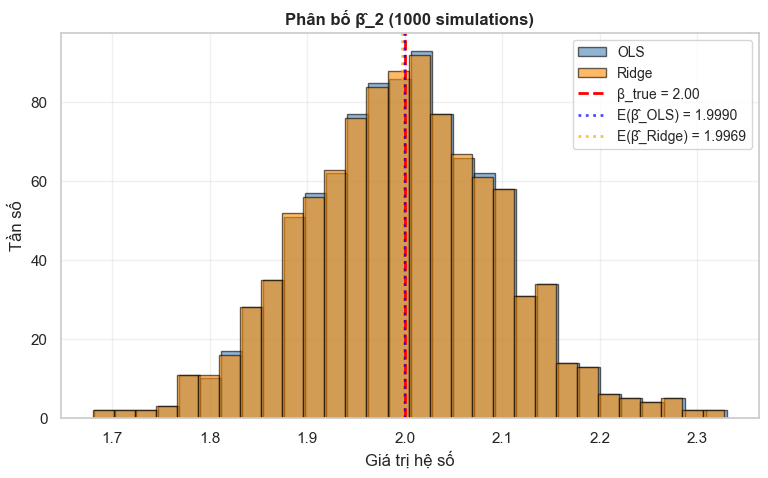

In [149]:
j = 2

plt.figure(figsize=(9, 5))

beta_ols = [results['beta_hat_ols'][i][j] for i in range(n_simulations)]
beta_ridge = [results['beta_hat_alt'][i][j] for i in range(n_simulations)]
beta_true = results['beta_true'][j]

plt.hist(beta_ols, bins=30, alpha=0.6, label='OLS', color='steelblue', edgecolor='black')
plt.hist(beta_ridge, bins=30, alpha=0.6, label='Ridge', color='darkorange', edgecolor='black')


plt.axvline(beta_true, color='red', linestyle='--', linewidth=2, label=f'β_true = {beta_true:.2f}')

mean_ols = results['mean_beta_ols'][j]
mean_ridge = results['mean_beta_alt'][j]
plt.axvline(mean_ols, color='blue', linestyle=':', linewidth=2, alpha=0.7, label=f'E(β̂_OLS) = {mean_ols:.4f}')
plt.axvline(mean_ridge, color='orange', linestyle=':', linewidth=2, alpha=0.7, label=f'E(β̂_Ridge) = {mean_ridge:.4f}')
plt.title(f'Phân bố β̂_{j} (1000 simulations)', fontsize=12, fontweight='bold')
plt.xlabel('Giá trị hệ số')
plt.ylabel('Tần số')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()

#### 8.7.3. Phân bố ước lượng hệ số góc ($\beta_2$)

Biểu đồ **"Phân bố $\beta_2$ (1000 simulations)"** trực quan hóa mật độ tần suất của các giá trị ước lượng $\hat{\beta}_2$ thu được từ 1000 lần lặp mô phỏng Monte Carlo cho cả hai mô hình OLS và Ridge Regression.

* **Về hình dáng phân bố:** Cả hai dải phân bố (OLS - màu xanh và Ridge - màu cam) đều thể hiện rõ cấu trúc hình chuông đối xứng đặc trưng của phân bố chuẩn. Kết quả thực nghiệm này tiếp tục củng cố Định lý Giới hạn Trung tâm (CLT), chứng minh rằng phân bố mẫu của ước lượng hệ số góc luôn hội tụ về phân bố Gauss khi số phiên mô phỏng đủ lớn.
* **Về tính chệch (Bias) đối với hệ số góc:** Đường kỳ vọng thực nghiệm của OLS ($E(\hat{\beta}_{OLS}) = 1.9990$, đường chấm xanh) tiệm cận sát với giá trị thực của tổng thể ($\beta_{true} = 2.00$, đường nét đứt đỏ) với độ chệch cực nhỏ ($\text{Bias}_{OLS} = -0.0010$). Trong khi đó, đường kỳ vọng thực nghiệm của Ridge ($E(\hat{\beta}_{Ridge}) = 1.9969$, đường chấm cam) bị dịch chuyển hẳn sang phía bên trái đường giá trị thực, hướng về phía gốc tọa độ $0$ với độ chệch lớn hơn ($\text{Bias}_{Ridge} = -0.0031$). Điều này minh chứng trực quan rằng Ridge Regression là một ước lượng có chệch (Biased Estimator).
* **Về phương sai và đặc thù của chính quy hóa $L_2$ (Ridge Penalty):** Kết quả thực nghiệm cho thấy Ridge Regression có phương sai nhỏ hơn nhẹ so với OLS: $Var_{Ridge} = 0.010071 < Var_{OLS} = 0.010093$. Điều này phản ánh cơ chế co ngót (*shrinkage*) của Ridge Regression, trong đó thành phần phạt $\lambda \|\beta\|_2^2$ chủ động kiểm soát độ lớn của hệ số nhằm hạn chế dao động trước nhiễu dữ liệu. Do đó, phân bố của Ridge có xu hướng tập trung hơn quanh giá trị trung bình so với OLS. Tuy nhiên, mức chênh lệch phương sai trong trường hợp này là khá nhỏ nên hai dải phân bố vẫn gần như chồng khít nhau trên biểu đồ. Kết quả này phù hợp với lý thuyết đánh đổi *Bias-Variance* của Ridge Regression.

### Plot 2: Bias của mỗi ước lượng

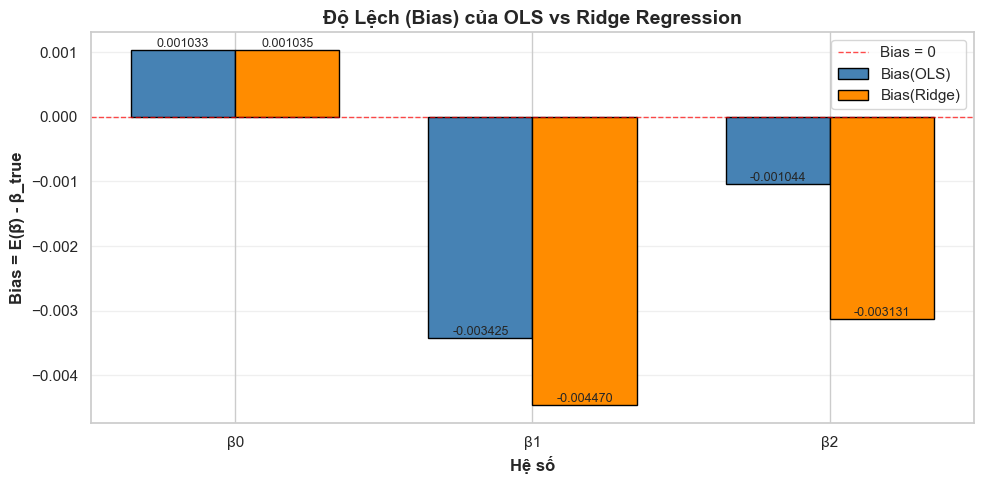

In [150]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(k)
width = 0.35

bias_ols = results['bias_ols']
bias_ridge = results['bias_alt']

bars1 = ax.bar(x_pos - width/2, bias_ols, width, label='Bias(OLS)', color='steelblue', edgecolor='black')
bars2 = ax.bar(x_pos + width/2, bias_ridge, width, label='Bias(Ridge)', color='darkorange', edgecolor='black')

ax.set_xlabel('Hệ số', fontsize=12, fontweight='bold')
ax.set_ylabel('Bias = E(β̂) - β_true', fontsize=12, fontweight='bold')
ax.set_title('Độ Lệch (Bias) của OLS vs Ridge Regression', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'β{i}' for i in range(k)])
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Bias = 0')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.6f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


#### 8.7.4. So sánh độ chệch (Bias) giữa OLS và Ridge Regression

Biểu đồ **"Độ Lệch (Bias) của OLS vs Ridge Regression"** trực quan hóa độ chệch thực nghiệm của các hệ số $\beta_0, \beta_1, \beta_2$ nhằm so sánh mức sai lệch giữa giá trị kỳ vọng của ước lượng và giá trị thực của tham số trong hai mô hình OLS và Ridge Regression.

* **Về xu hướng tổng quát của độ chệch:** Đường tham chiếu màu đỏ tại mức $Bias = 0$ biểu thị trạng thái ước lượng không chệch lý tưởng. Quan sát biểu đồ cho thấy các hệ số của OLS đều nằm gần đường này hơn so với Ridge Regression, phản ánh tính chất gần không chệch của OLS trong khi Ridge chấp nhận một lượng độ chệch nhất định do tác động của chính quy hóa $L_2$.

* **Về hệ số chặn ($\beta_0$):** Cả OLS và Ridge đều cho giá trị độ chệch rất nhỏ và gần như tương đương nhau ($Bias_{OLS} \approx Bias_{Ridge} \approx 0.001$). Điều này phù hợp với bản chất của Ridge Regression khi hệ số chặn $\beta_0$ thường không chịu tác động trực tiếp từ thành phần phạt $L_2$.

* **Về các hệ số góc ($\beta_1, \beta_2$):** Biểu đồ cho thấy độ chệch của Ridge Regression có giá trị âm lớn hơn so với OLS tại cả hai hệ số góc. Cụ thể, tại $\beta_1$, độ chệch thay đổi từ $-0.003425$ (OLS) xuống $-0.004470$ (Ridge). Tương tự, tại $\beta_2$, độ chệch thay đổi từ $-0.001044$ xuống $-0.003131$. Điều này phản ánh rõ cơ chế co ngót (*shrinkage*) của Ridge Regression, trong đó các hệ số bị kéo nhẹ về phía gốc tọa độ $0$ dưới tác động của hàm phạt $\lambda \|\beta\|_2^2$.

* **Về ý nghĩa thống kê của hiện tượng co ngót:** Kết quả trực quan cho thấy Ridge Regression chấp nhận gia tăng một lượng độ chệch nhỏ nhằm đổi lấy sự ổn định cao hơn của mô hình trước nhiễu dữ liệu. Đây là cơ chế cốt lõi của lý thuyết đánh đổi *Bias-Variance*, trong đó mô hình cho phép tăng nhẹ độ chệch để giảm dao động của ước lượng và cải thiện khả năng tổng quát hóa trên dữ liệu mới.

### Plot 3: Phương sai của mỗi ước lượng

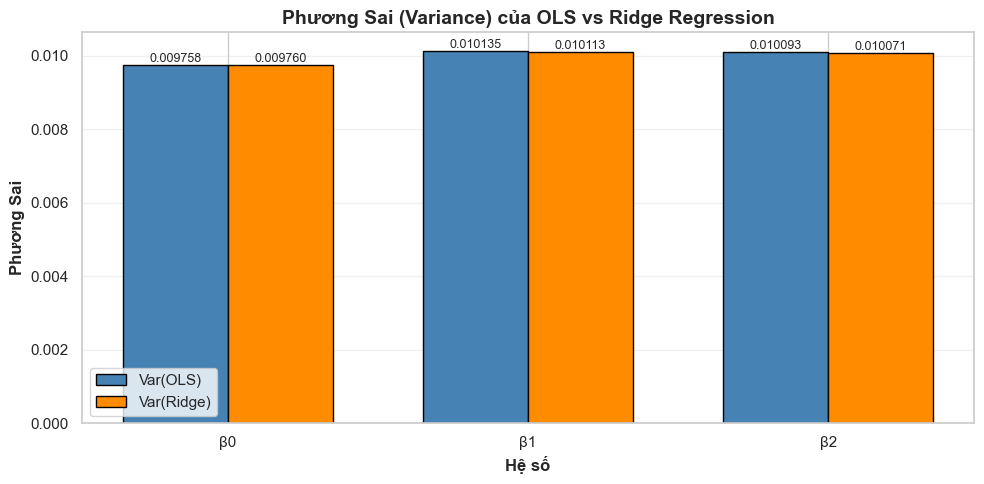

In [151]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(k)
width = 0.35

var_ols = results['var_ols']
var_ridge = results['var_alt']

bars1 = ax.bar(x_pos - width/2, var_ols, width, label='Var(OLS)', color='steelblue', edgecolor='black')
bars2 = ax.bar(x_pos + width/2, var_ridge, width, label='Var(Ridge)', color='darkorange', edgecolor='black')

ax.set_xlabel('Hệ số', fontsize=12, fontweight='bold')
ax.set_ylabel('Phương Sai', fontsize=12, fontweight='bold')
ax.set_title('Phương Sai (Variance) của OLS vs Ridge Regression', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'β{i}' for i in range(k)])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)


for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.6f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


#### 8.7.5. So sánh phương sai (Variance) giữa OLS và Ridge Regression

Biểu đồ **"Phương Sai (Variance) của OLS vs Ridge Regression"** trực quan hóa mức độ dao động thực nghiệm của các hệ số ước lượng $\beta_0, \beta_1, \beta_2$ nhằm so sánh tính ổn định của hai phương pháp OLS và Ridge Regression qua 1000 lần mô phỏng Monte Carlo.

* **Về xu hướng tổng quát của phương sai:** Quan sát biểu đồ cho thấy phương sai của Ridge Regression đều nhỏ hơn hoặc xấp xỉ OLS tại tất cả các hệ số. Điều này phản ánh đúng bản chất của Ridge Regression khi thành phần phạt chính quy hóa $L_2$ có tác dụng kiểm soát mức dao động của các hệ số ước lượng trước nhiễu ngẫu nhiên từ dữ liệu mẫu.

* **Về hệ số chặn ($\beta_0$):** Phương sai của hai mô hình gần như tương đương nhau ($Var_{OLS} = 0.009758$, $Var_{Ridge} = 0.009760$). Kết quả này phù hợp với cơ chế của Ridge Regression vì hệ số chặn $\beta_0$ thường không chịu tác động trực tiếp từ thành phần phạt $L_2$, khiến mức dao động thực nghiệm giữa hai mô hình gần như không thay đổi.

* **Về các hệ số góc ($\beta_1, \beta_2$):** Tại hai hệ số góc, Ridge Regression cho phương sai nhỏ hơn nhẹ so với OLS. Cụ thể:
$Var_{Ridge}(\beta_1) = 0.010113 < Var_{OLS}(\beta_1) = 0.010135$ và $Var_{Ridge}(\beta_2) = 0.010071 < Var_{OLS}(\beta_2) = 0.010093$. Sự suy giảm này phản ánh cơ chế co ngót (*shrinkage*) của Ridge Regression, trong đó các hệ số bị kéo nhẹ về phía gốc tọa độ $0$ nhằm hạn chế mức độ dao động của ước lượng.

* **Về ý nghĩa của việc giảm phương sai:** Mặc dù mức chênh lệch phương sai giữa Ridge và OLS này là khá nhỏ, kết quả vẫn cho thấy Ridge Regression giúp mô hình ổn định hơn trước biến động của dữ liệu mẫu. Đây chính là nền tảng của cơ chế đánh đổi *Bias-Variance*, trong đó mô hình chấp nhận gia tăng một lượng độ chệch nhỏ để đổi lấy sự suy giảm phương sai và cải thiện khả năng tổng quát hóa trên dữ liệu mới.

### Plot 4: MSE Comparison

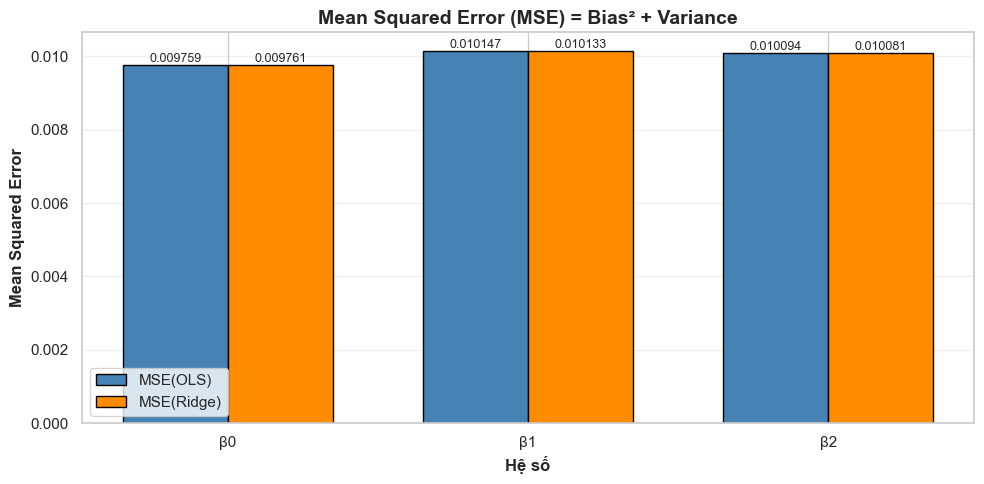

In [152]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(k)
width = 0.35

mse_ols = mse_ols_list
mse_ridge = mse_ridge_list

bars1 = ax.bar(x_pos - width/2, mse_ols, width, label='MSE(OLS)', color='steelblue', edgecolor='black')
bars2 = ax.bar(x_pos + width/2, mse_ridge, width, label='MSE(Ridge)', color='darkorange', edgecolor='black')

ax.set_xlabel('Hệ số', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
ax.set_title('Mean Squared Error (MSE) = Bias² + Variance', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'β{i}' for i in range(k)])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.6f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


#### 8.7.6. So sánh Sai số bình phương trung bình (MSE) giữa OLS và Ridge Regression

Biểu đồ **"Mean Squared Error (MSE) = $Bias^2$ + Variance"** trực quan hóa tổng sai số thực nghiệm của các hệ số ước lượng $\beta_0, \beta_1, \beta_2$ nhằm đánh giá toàn diện hiệu năng thống kê giữa hai phương pháp OLS và Ridge Regression qua 1000 lần mô phỏng Monte Carlo.

- **Về ý nghĩa thống kê của MSE:** Chỉ số Mean Squared Error (MSE) phản ánh tổng hợp đồng thời hai thành phần sai số cốt lõi của một ước lượng, bao gồm bình phương độ chệch ($Bias^2$) và phương sai ($Variance$): $MSE(\hat{\beta}) = Bias(\hat{\beta})^2 + Var(\hat{\beta})$

Do đó, MSE được xem là thước đo toàn diện nhất để đánh giá chất lượng của một bộ ước lượng, vì nó đồng thời phản ánh cả mức độ chính xác và tính ổn định của mô hình.

- **Về hệ số chặn ($\beta_0$):** Biểu đồ cho thấy giá trị MSE của OLS và Ridge Regression gần như tương đương nhau: $MSE_{OLS} = 0.009759, MSE_{Ridge} = 0.009761$. Sự chênh lệch gần như không đáng kể này phản ánh việc hệ số chặn $\beta_0$ không chịu tác động trực tiếp từ thành phần phạt $L_2$, khiến cả độ chệch và phương sai của hai mô hình duy trì ở mức gần tương đồng.

- **Về các hệ số góc ($\beta_1, \beta_2$):** Tại hai hệ số góc, Ridge Regression cho giá trị MSE nhỏ hơn nhẹ so với OLS. Cụ thể: $MSE_{Ridge}(\beta_1) = 0.010133 < MSE_{OLS}(\beta_1) = 0.010147$ và $MSE_{Ridge}(\beta_2) = 0.010081 < MSE_{OLS}(\beta_2) = 0.010094$. Mặc dù Ridge Regression làm gia tăng một lượng độ chệch nhỏ do cơ chế co ngót (*shrinkage*), sự suy giảm phương sai đạt được lại lớn hơn phần gia tăng của $Bias^2$, khiến tổng sai số MSE được cải thiện nhẹ so với OLS.

- **Về cơ chế đánh đổi Bias-Variance:** Kết quả trực quan của biểu đồ phản ánh đúng bản chất lý thuyết của Ridge Regression trong bài toán đánh đổi *Bias-Variance*. Thay vì theo đuổi trạng thái gần như không chệch tuyệt đối như OLS, Ridge chủ động chấp nhận một lượng độ chệch nhỏ nhằm làm giảm dao động của các hệ số ước lượng trước nhiễu dữ liệu. Hệ quả là mô hình đạt được cấu trúc ổn định hơn và có khả năng tổng quát hóa tốt hơn trên dữ liệu mới.

- **Về mức độ cải thiện thực nghiệm:** Mặc dù sự khác biệt MSE giữa OLS và Ridge Regression trong thí nghiệm này là khá nhỏ do dữ liệu mô phỏng chưa xuất hiện đa cộng tuyến mạnh hoặc mức nhiễu lớn, biểu đồ vẫn cho thấy xu hướng nhất quán với lý thuyết Ridge Regression: mô hình chính quy hóa có khả năng tối ưu hóa tổng sai số bằng cách cân bằng hợp lý giữa độ chệch và phương sai.

### Plot 5: Bias-Variance Tradeoff

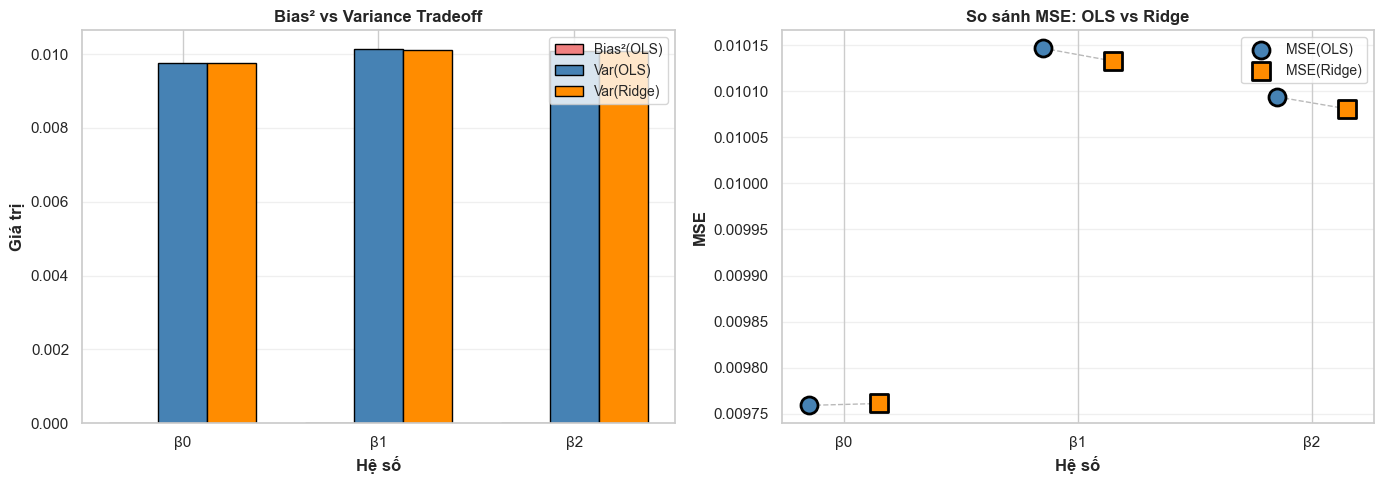

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = np.arange(k)
width = 0.25

bias_sq_ols = [b**2 for b in bias_ols]
bias_sq_ridge = [b**2 for b in bias_ridge]

ax.bar(x_pos - width, bias_sq_ols, width, label='Bias²(OLS)', color='lightcoral', edgecolor='black')
ax.bar(x_pos, var_ols, width, label='Var(OLS)', color='steelblue', edgecolor='black')
ax.bar(x_pos + width, var_ridge, width, label='Var(Ridge)', color='darkorange', edgecolor='black')

ax.set_xlabel('Hệ số', fontsize=12, fontweight='bold')
ax.set_ylabel('Giá trị', fontsize=12, fontweight='bold')
ax.set_title('Bias² vs Variance Tradeoff', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'β{i}' for i in range(k)])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
x_labels = [f'β{i}' for i in range(k)]
x_pos_scatter = np.arange(k)

ax.scatter(x_pos_scatter - 0.15, mse_ols, s=150, marker='o', color='steelblue',
          label='MSE(OLS)', edgecolor='black', linewidth=2, zorder=3)
ax.scatter(x_pos_scatter + 0.15, mse_ridge, s=150, marker='s', color='darkorange',
          label='MSE(Ridge)', edgecolor='black', linewidth=2, zorder=3)

for i in range(k):
    ax.plot([i-0.15, i+0.15], [mse_ols[i], mse_ridge[i]], 'k--', alpha=0.3, linewidth=1)

ax.set_xlabel('Hệ số', fontsize=12, fontweight='bold')
ax.set_ylabel('MSE', fontsize=12, fontweight='bold')
ax.set_title('So sánh MSE: OLS vs Ridge', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos_scatter)
ax.set_xticklabels(x_labels)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


#### 8.7.7. Bias-Variance Tradeoff và So sánh MSE giữa OLS và Ridge Regression

Hình trực quan bao gồm hai biểu đồ bổ trợ lẫn nhau nhằm mô tả toàn diện cơ chế đánh đổi *Bias-Variance* và tác động của Ridge Regression lên tổng sai số MSE của các hệ số $\beta_0, \beta_1, \beta_2$.

#### 8.7.8. $Bias^2$ vs Variance Tradeoff

Biểu đồ bên trái trực quan hóa mối quan hệ giữa bình phương độ chệch ($Bias^2$) và phương sai ($Variance$) của OLS và Ridge Regression.

- Về xu hướng tổng quát của $Bias^2$ và Variance:
  - Quan sát biểu đồ cho thấy thành phần phương sai (*Variance*) chiếm ưu thế gần như tuyệt đối trong tổng sai số MSE của cả hai mô hình, trong khi giá trị $Bias^2$ gần như tiệm cận $0$. Điều này xảy ra do cả OLS và Ridge Regression trong thí nghiệm đều chỉ tạo ra độ chệch rất nhỏ.
  - Mặc dù Ridge Regression làm gia tăng nhẹ giá trị $Bias^2$ do tác động của cơ chế co ngót (*shrinkage*), sự thay đổi này là rất nhỏ so với quy mô của phương sai tổng thể.
- Về hệ số chặn ($\beta_0$): Tại hệ số chặn $\beta_0$, phương sai của OLS và Ridge gần như tương đương nhau. Điều này phù hợp với bản chất của Ridge Regression khi hệ số chặn thường không tham gia trực tiếp vào thành phần phạt $L_2$, khiến mức dao động của hai mô hình duy trì gần như giống nhau.

- Về các hệ số góc ($\beta_1, \beta_2$)
  - Đối với các hệ số góc, Ridge Regression cho phương sai nhỏ hơn nhẹ so với OLS. Đây là hệ quả trực tiếp của cơ chế chính quy hóa: $\lambda \|\beta\|_2^2$. Trong đó các hệ số bị kéo nhẹ về phía gốc tọa độ $0$ nhằm hạn chế dao động quá mức trước nhiễu dữ liệu. Tuy nhiên, mức suy giảm phương sai trong thí nghiệm này là khá nhỏ nên chiều cao các cột giữa OLS và Ridge gần như chồng khít nhau trên biểu đồ.

- Về ý nghĩa của cơ chế đánh đổi Bias-Variance

  - Biểu đồ phản ánh đúng nguyên lý nền tảng của Ridge Regression: mô hình chấp nhận gia tăng một lượng độ chệch nhỏ để đổi lấy sự ổn định cao hơn của các hệ số ước lượng. Đây chính là cơ chế đánh đổi *Bias-Variance* nhằm cải thiện khả năng tổng quát hóa của mô hình trên dữ liệu mới.

#### 8.7.9. So sánh MSE: OLS vs Ridge
Biểu đồ bên phải trực quan hóa sự thay đổi của tổng sai số bình phương trung bình (MSE) giữa OLS và Ridge Regression.

- Về cấu trúc trực quan của MSE: các điểm tròn màu xanh biểu diễn MSE của OLS, trong khi các điểm vuông màu cam biểu diễn MSE của Ridge Regression. Các đường nét đứt nối giữa hai điểm giúp thể hiện trực quan xu hướng thay đổi của tổng sai số khi mô hình chuyển từ OLS sang Ridge.
- Về hệ số chặn ($\beta_0$)
  - Tại $\beta_0$, MSE của hai mô hình gần như tương đương: $MSE_{OLS} \approx 0.009759$ và $MSE_{Ridge} \approx 0.009761$. Điều này phản ánh việc Ridge gần như không tác động lên hệ số chặn nên cả độ chệch và phương sai của hai mô hình duy trì tương tự nhau.

- Về các hệ số góc ($\beta_1, \beta_2$)

Tại hai hệ số góc, Ridge Regression cho MSE nhỏ hơn nhẹ so với OLS: $MSE_{Ridge}(\beta_1) < MSE_{OLS}(\beta_1)$ và $MSE_{Ridge}(\beta_2) < MSE_{OLS}(\beta_2)$. Kết quả này cho thấy phần suy giảm phương sai của Ridge lớn hơn mức gia tăng của $Bias^2$, khiến tổng sai số MSE được cải thiện nhẹ.

- Về ý nghĩa thống kê tổng quát
  - Mặc dù mức cải thiện MSE trong thí nghiệm này chưa lớn do dữ liệu mô phỏng chưa xuất hiện đa cộng tuyến mạnh hoặc mức nhiễu cao, xu hướng trực quan của biểu đồ vẫn hoàn toàn phù hợp với lý thuyết Ridge Regression. Mô hình chính quy hóa có khả năng tạo ra cấu trúc ổn định hơn bằng cách cân bằng hợp lý giữa độ chệch và phương sai, từ đó cải thiện khả năng dự báo trên dữ liệu chưa quan sát.